#Phishing Websites

# To-Do List: Baseline Models

1. Harris
   - Random Forest
   - ROC AUC Curves

2. Sanjana
   - XGBoost
   - ROC AUC

3. Jose
   - RNN
   - ROC AUC Curve

**All models will report:**
- Accuracy
- Precision
- Recall
- Confusion Matrix

# Initial Setup

In [2]:
# Installing Packages comment out if not needed
# %pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 30.1 MB/s eta 0:00:00


# Import all libraries

In [3]:
import os
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import copy
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, ParameterGrid, KFold
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc, roc_auc_score, ConfusionMatrixDisplay
from xgboost import XGBClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv
from sklearn.neighbors import kneighbors_graph



In [4]:
# Mounting your Google drive to your Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
print(os.listdir('/content/drive/MyDrive/')) # Clear output after confirming it runs

['graduation.mp4', 'video.mp4', 'Harris Durrani cover letter.docx', 'Harris Durrani Resume (1).docx', 'Untitled Jam.pdf', 'Anisa Siddiqui Resume.pdf', 'Harris Durrani.pdf', 'Harris Durrani.gdoc', 'Anisa Siddiqui Resume.gdoc', 'Harris Durrani Resume.pdf', 'image0.jpeg', 'Harris Durrani Resume.docx', 'Tuition statement.png', 'Oral Exam Harris Durrani.pptx', 'image001.jpg', 'Machine Learning Progress Status.gslides', 'Copy of Linguaero Urdu .gdoc', 'The Mechanics of Ensemble Learning Methods.gdoc', 'Foundations of Probabilistic Machine Learning Study Guide.gdoc', 'Foundations of Generalized Linear Models Study Guide (1).gdoc', 'Architectures and Applications of GLM Link Functions.gdoc', 'Foundations of Generalized Linear Models Study Guide.gdoc', 'Colab Notebooks', 'Future Travel plans with planner.gsheet', 'Advanced AI Project', '.ipynb_checkpoints', 'CAP5636_W9_DeepGenerativeModels_AE_VAE_GAN_Diffusion_Final Version.ipynb']


# Preview of data

In [6]:
# Initial Setup - Importing all libraries and files
file_path = '/content/drive/MyDrive/Advanced AI Project/phishing_websites.csv'
df  = pd.read_csv(file_path)
df.head()

,having_ip_address,url_length,shortining_service,having_at_symbol,double_slash_redirecting,prefix_suffix,having_sub_domain,sslfinal_state,domain_registration_length,favicon,...,popupwindow,iframe,age_of_domain,dnsrecord,web_traffic,page_rank,google_index,links_pointing_to_page,statistical_report,result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,...,-1,1,-1,-1,0,-1,1,1,1,1


In [7]:
# Initial Code added to extract each model's results for final comparision.
model_results = []
roc_curves_results = []



---



# Random Forest

In [8]:
X = df.drop('result', axis=1).values
y = df['result'].map({-1: 0, 1: 1}).values

# Step 1: split off 70% train, 30% remaining
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=6704
)

# Step 2: split the remaining 30% evenly into 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=1996
)




In [9]:
rf_classifier = RandomForestClassifier(
    n_estimators=100,      # Number of decision trees
    max_depth=None,        # Trees grow until leaves are pure
    random_state=42,       # Ensures reproducible splits and results
    n_jobs=-1              # Use all available CPU cores for parallel processing
)

rf_classifier.fit(X_train, y_train)
val_preds = rf_classifier.predict(X_val)
val_accuracy = accuracy_score(y_val, val_preds)
print(f"Validation Accuracy: {val_accuracy:.4f}")

y_pred = rf_classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)



Validation Accuracy: 0.9668


Accuracy:  0.9620
Precision: 0.9623
Recall:    0.9620
F1 Score:  0.9620


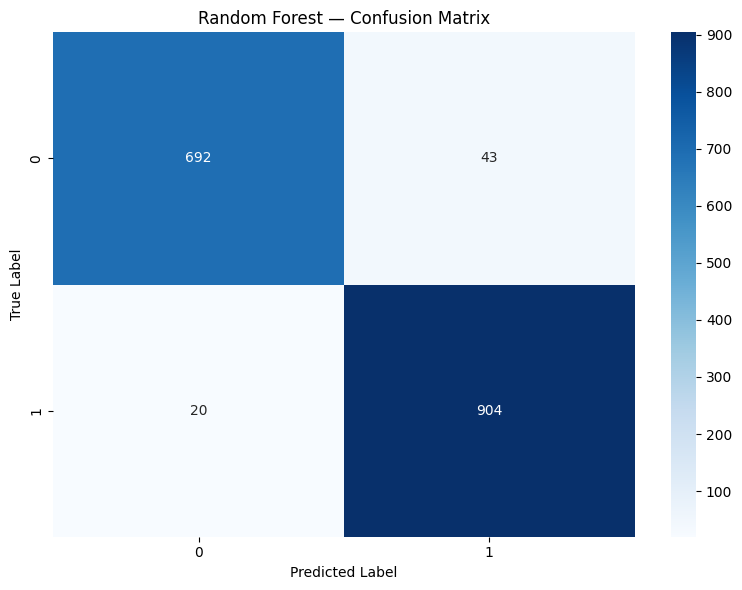

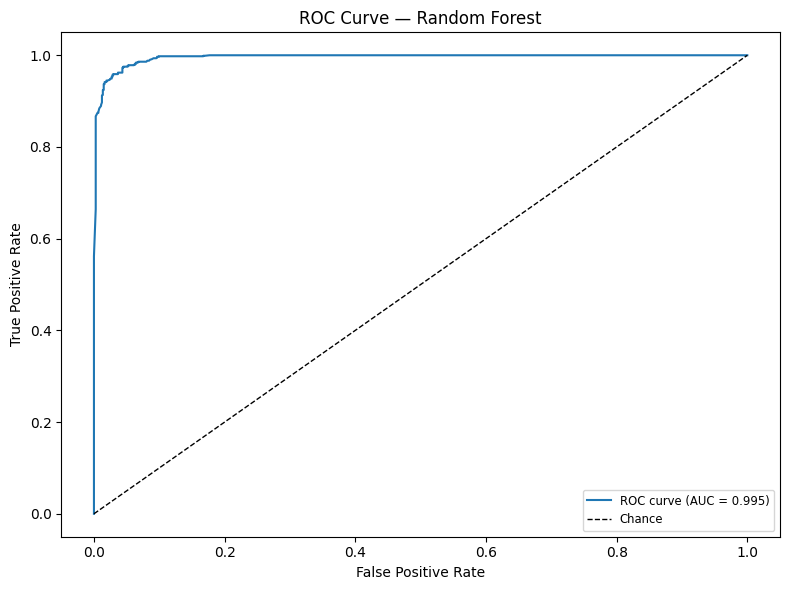

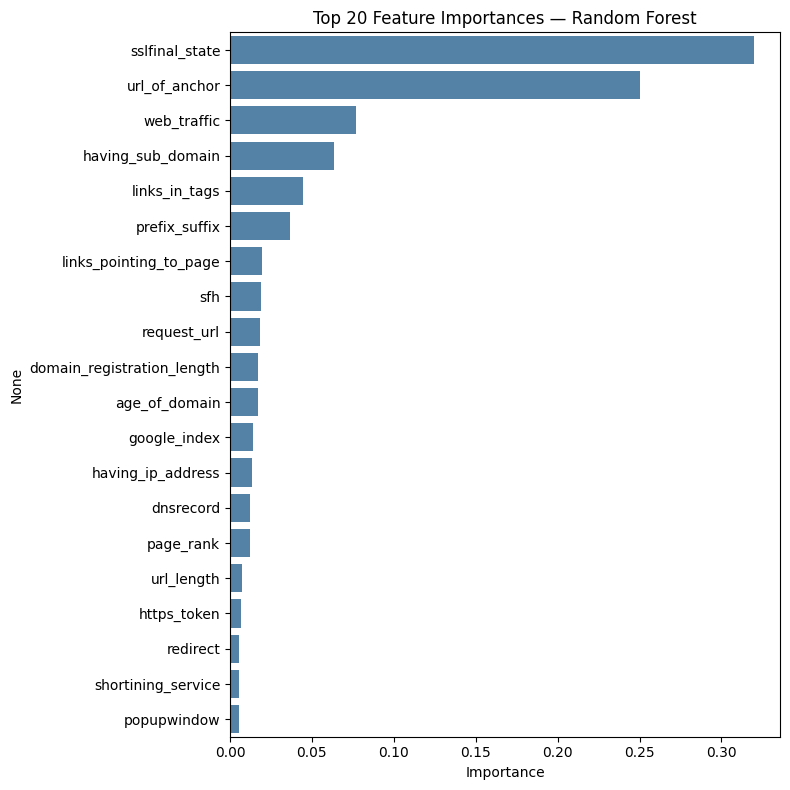

In [10]:
# ---- Basic metrics ----
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

classes = rf_classifier.classes_
n_classes = len(classes)

# ---- Confusion Matrix ----
cm = confusion_matrix(y_test, y_pred, labels=classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.show()

# ---- ROC Curve(s) ----
y_score = rf_classifier.predict_proba(X_test)

plt.figure(figsize=(8, 6))

if n_classes == 2:
    # Binary case
    fpr, tpr, _ = roc_curve(y_test, y_score[:, 1], pos_label=classes[1])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
else:
    # Multi-class: one-vs-rest
    y_test_bin = label_binarize(y_test, classes=classes)
    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{cls} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Random Forest')
plt.legend(loc='lower right', fontsize='small')
plt.tight_layout()
plt.show()

# ---- Feature Importance ----
importances = pd.Series(rf_classifier.feature_importances_, index=df.drop('result', axis=1).columns)
importances = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(8, 8))
sns.barplot(x=importances.values, y=importances.index, color='steelblue')
plt.xlabel('Importance')
plt.title('Top 20 Feature Importances — Random Forest')
plt.tight_layout()
plt.show()



---



In [11]:
# Adding Results for comparison
model_results.append({
    'Model': 'Random Forest',
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1 Score': f1
})

roc_curves_results.append({
    'Model': 'Random Forest',
    'fpr': fpr,
    'tpr': tpr,
    'roc_auc': roc_auc
})

#XGBoost

#Importing Libraries & Data Preparation

In [12]:
# XGBoost — Imports & Data Prep
# (Self-contained: rebuilds the same 70/15/15 split used by the Random Forest
#  section so the two models are directly comparable.)
# Features / target. Trees don't require standardization, so no scaler here.
X = df.drop('result', axis=1).values
y = df['result'].map({-1: 0, 1: 1}).values          # 1 = phishing, 0 = safe
feature_names = df.drop('result', axis=1).columns

# Step 1: 70% train, 30% remaining
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=6704
)

# Step 2: split the remaining 30% evenly into 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=1996
)

print(f"Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}")

Train: (7738, 30)  Val: (1658, 30)  Test: (1659, 30)


#Model: XGBoost Classifier

In [13]:
# Training the XGBoost classifier
# The validation set is used for early stopping, so n_estimators is an upper
# bound rather than a fixed count — training halts once val logloss stops improving.
xgb_classifier = XGBClassifier(
    n_estimators=500,            # Upper bound on boosting rounds
    learning_rate=0.1,           # Step size shrinkage
    max_depth=6,                 # Max tree depth (controls interaction complexity)
    subsample=0.8,               # Row sampling per tree — reduces overfitting
    colsample_bytree=0.8,        # Feature sampling per tree
    reg_lambda=1.0,              # L2 regularization on leaf weights
    objective='binary:logistic',
    eval_metric='logloss',
    early_stopping_rounds=25,    # Stop if val logloss doesn't improve for 25 rounds
    random_state=42,
    n_jobs=-1
)

xgb_classifier.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print(f"Best iteration (early stopping): {xgb_classifier.best_iteration}")

val_preds = xgb_classifier.predict(X_val)
val_accuracy = accuracy_score(y_val, val_preds)
print(f"Validation Accuracy: {val_accuracy:.4f}")

# Test-set predictions: probabilities for ROC, hard labels for the other metrics
y_pred_prob_xgb = xgb_classifier.predict_proba(X_test)[:, 1]
y_pred_xgb = (y_pred_prob_xgb >= 0.5).astype(int)

Best iteration (early stopping): 325
Validation Accuracy: 0.9704


##Metrics


--- XGBoost Metrics (Test Set) ---
Accuracy:  0.9632
Precision: 0.9615
Recall:    0.9729
F1 Score:  0.9672
ROC AUC:   0.9960

--- Confusion Matrix Breakdown ---
True Negatives (TN):  699 (Actually Safe, Predicted Safe)
False Positives (FP): 36 (Actually Safe, Predicted Phishing - False Alarm)
False Negatives (FN): 25 (Actually Phishing, Predicted Safe - Missed Threat)
True Positives (TP):  899 (Actually Phishing, Predicted Phishing)


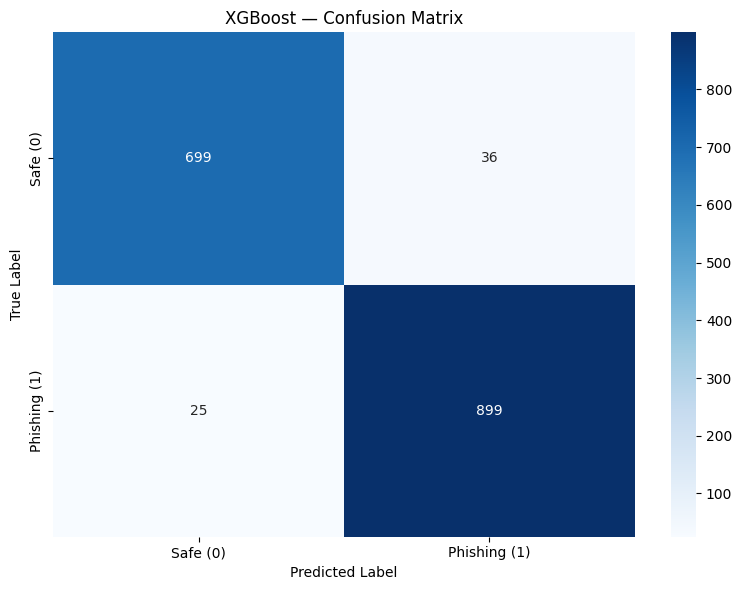

In [14]:
# Storing results for comparing models
accuracy_XGB  = accuracy_score(y_test, y_pred_xgb)
precision_XGB = precision_score(y_test, y_pred_xgb)
recall_XGB    = recall_score(y_test, y_pred_xgb)
f1_XGB        = f1_score(y_test, y_pred_xgb)
roc_auc_XGB   = roc_auc_score(y_test, y_pred_prob_xgb)

print("\n--- XGBoost Metrics (Test Set) ---")
print(f"Accuracy:  {accuracy_XGB:.4f}")
print(f"Precision: {precision_XGB:.4f}")
print(f"Recall:    {recall_XGB:.4f}")
print(f"F1 Score:  {f1_XGB:.4f}")
print(f"ROC AUC:   {roc_auc_XGB:.4f}")

# ---- Confusion Matrix ----
cm = confusion_matrix(y_test, y_pred_xgb)
tn, fp, fn, tp = cm.ravel()

print("\n--- Confusion Matrix Breakdown ---")
print(f"True Negatives (TN):  {tn} (Actually Safe, Predicted Safe)")
print(f"False Positives (FP): {fp} (Actually Safe, Predicted Phishing - False Alarm)")
print(f"False Negatives (FN): {fn} (Actually Phishing, Predicted Safe - Missed Threat)")
print(f"True Positives (TP):  {tp} (Actually Phishing, Predicted Phishing)")

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Safe (0)', 'Phishing (1)'],
            yticklabels=['Safe (0)', 'Phishing (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('XGBoost — Confusion Matrix')
plt.tight_layout()
plt.show()

##ROC AUC Curve

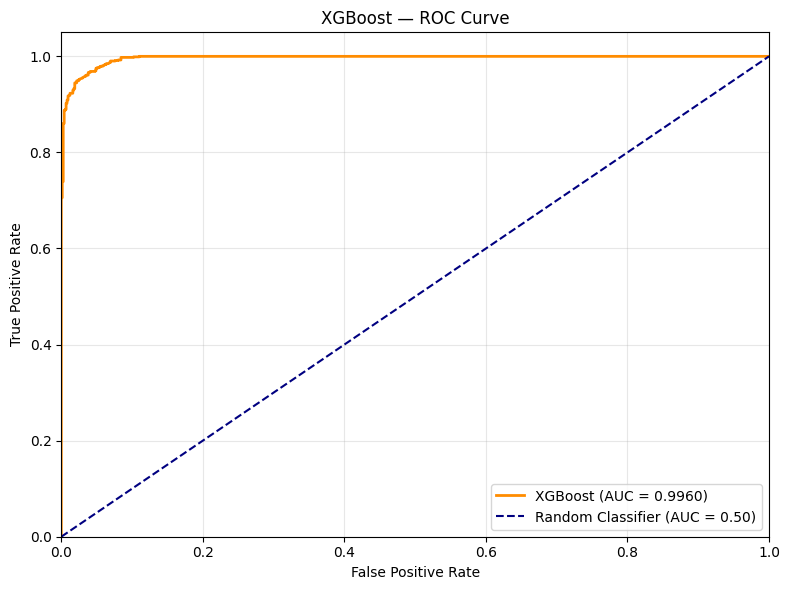

ROC AUC: 0.9960


In [15]:
# ---- ROC Curve ----
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob_xgb)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'XGBoost (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--',
         label='Random Classifier (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost — ROC Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"ROC AUC: {roc_auc:.4f}")

##Feature Importance

--- Top 10 Features ---
           Feature  Importance  Importance %
     url_of_anchor    0.249384     24.938385
    sslfinal_state    0.205005     20.500525
     prefix_suffix    0.180893     18.089254
shortining_service    0.034310      3.431006
       web_traffic    0.032342      3.234237
               sfh    0.021303      2.130278
 having_sub_domain    0.020777      2.077687
     links_in_tags    0.018351      1.835094
      google_index    0.016588      1.658789
           favicon    0.014845      1.484481


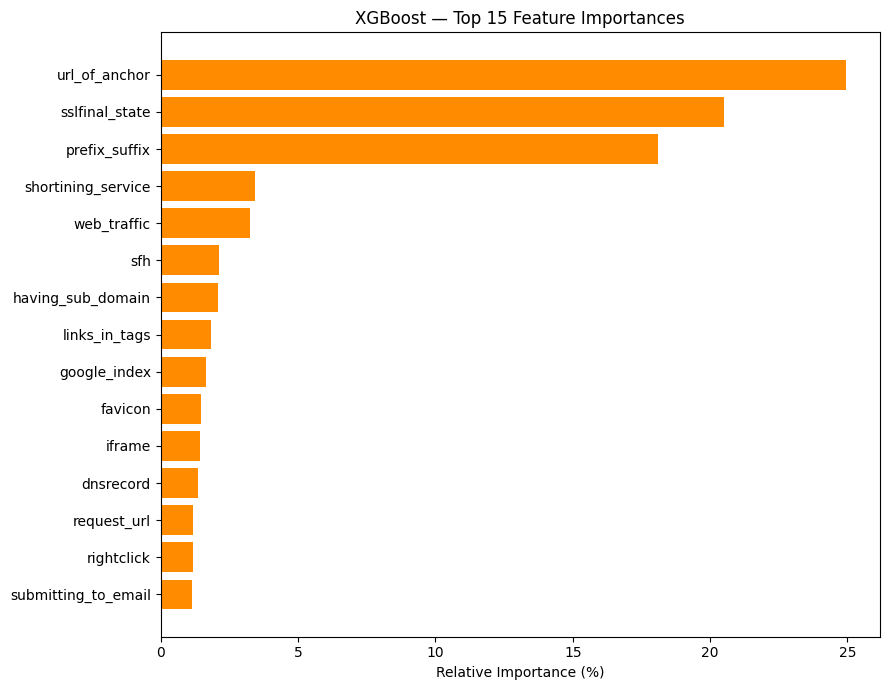

In [16]:
# ---- Feature Importance (gain-based, native to XGBoost) ----
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_classifier.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

importance_df['Importance %'] = (
    importance_df['Importance'] / importance_df['Importance'].sum() * 100
)

print("--- Top 10 Features ---")
print(importance_df.head(10).to_string(index=False))

top_n = importance_df.head(15).iloc[::-1]
plt.figure(figsize=(9, 7))
plt.barh(top_n['Feature'], top_n['Importance %'], color='darkorange')
plt.xlabel('Relative Importance (%)')
plt.title('XGBoost — Top 15 Feature Importances')
plt.tight_layout()
plt.show()

In [17]:
# Adding Results for comparison
model_results.append({
    'Model': 'XGBoost',
    'Accuracy': accuracy_XGB,
    'Precision': precision_XGB,
    'Recall': recall_XGB,
    'F1 Score': f1_XGB
})

roc_curves_results.append({
    'Model': 'XGBoost',
    'fpr': fpr,
    'tpr': tpr,
    'roc_auc': roc_auc_XGB
})



---



#RNN

## Data Preparation

In [19]:
# Inspecting for class proprtions
# 1. View the exact number of instances for each class
print("--- Raw Counts ---")
print(df['result'].value_counts())

# 2. View the percentage breakdown of each class
print("\n--- Percentages ---")
print((df['result'].value_counts(normalize=True) * 100).apply(lambda x: f"{x:.2f}%"))

--- Raw Counts ---
result
 1    6157
-1    4898
Name: count, dtype: int64

--- Percentages ---
result
 1    55.69%
-1    44.31%
Name: proportion, dtype: object


## Splitting Train and Test Data

In [20]:
# Separating features and target
X = df.drop('result', axis=1).values
y = df['result'].map({-1: 0, 1: 1}).values

# Splitting Train/Test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Reshaping for RNN:
X_train_rnn = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_rnn = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))


## Model #1: Simple RNN

In [21]:
# Building Simple RNN
model = Sequential([
    SimpleRNN(
        32,
        activation='relu',
        input_shape=(X_train_rnn.shape[1], X_train_rnn.shape[2])),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Training & Testing the RNN Model

In [22]:
# Training Model
print("Training the RNN...")
history = model.fit(X_train_rnn, y_train, epochs=15, batch_size=32, validation_split=0.1, verbose=1)

# Getting probability predictions and binary class predictions
y_pred_prob = model.predict(X_test_rnn).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)



Training the RNN...
Epoch 1/15
249/249 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8174 - loss: 0.4048 - val_accuracy: 0.9367 - val_loss: 0.1837
Epoch 2/15
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9168 - loss: 0.2066 - val_accuracy: 0.9446 - val_loss: 0.1543
Epoch 3/15
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9239 - loss: 0.1885 - val_accuracy: 0.9435 - val_loss: 0.1428
Epoch 4/15
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9293 - loss: 0.1745 - val_accuracy: 0.9480 - val_loss: 0.1374
Epoch 5/15
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9342 - loss: 0.1625 - val_accuracy: 0.9458 - val_loss: 0.1331
Epoch 6/15
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9327 - loss: 0.1578 - val_accuracy: 0.9492 - val_loss: 0.1302
Epoch 7/15
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9383 - loss: 0.1498 - val_accuracy: 0.9514 - val_loss: 0.1302
Epoch 8/15
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9408 - loss: 0.14

### Metrics


--- Baseline RNN Metrics ---
Accuracy:  0.9512
Precision: 0.9453
Recall:    0.9683
F1 Score:  0.9567

Confusion Matrix:
[[ 911   69]
 [  39 1192]]

--- Confusion Matrix Breakdown ---
True Negatives (TN):  911 (Actually Safe, Predicted Safe)
False Positives (FP): 69 (Actually Safe, Predicted Phishing - False Alarm)
False Negatives (FN): 39 (Actually Phishing, Predicted Safe - Missed Threat)
True Positives (TP):  1192 (Actually Phishing, Predicted Phishing)


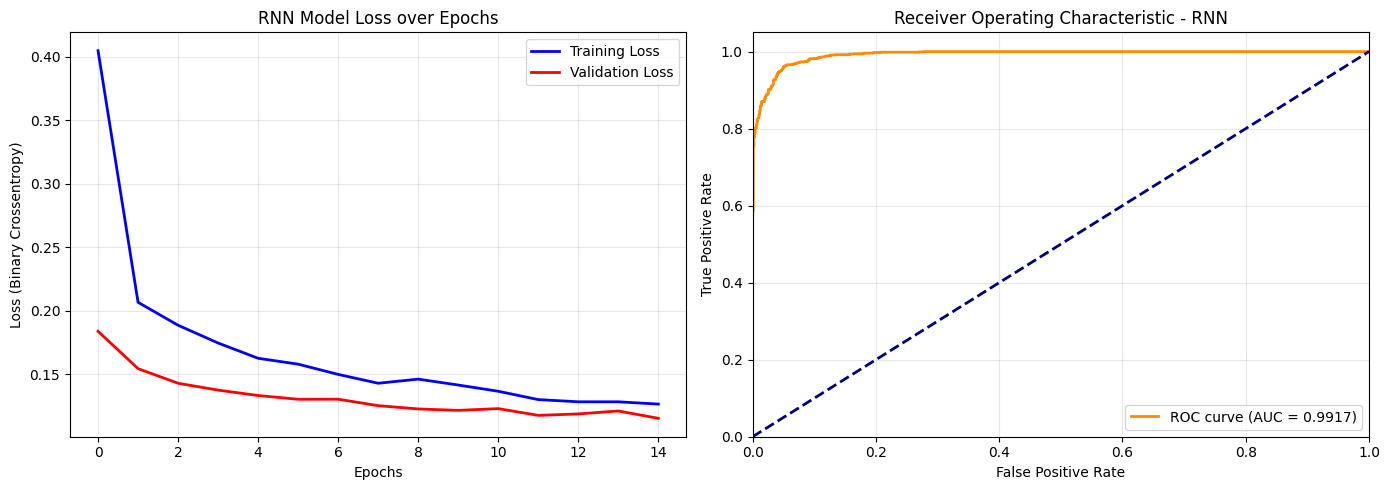

In [23]:
# Storing results for comparing models
accuracy_RNN1 = accuracy_score(y_test, y_pred)
precision_RNN1 = precision_score(y_test, y_pred)
recall_RNN1 = recall_score(y_test, y_pred)
f1_RNN1 = f1_score(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

# Displaying metrics
print("\n--- Baseline RNN Metrics ---")
print(f"Accuracy:  {accuracy_RNN1:.4f}")
print(f"Precision: {precision_RNN1:.4f}")
print(f"Recall:    {recall_RNN1:.4f}")
print(f"F1 Score:  {f1_RNN1:.4f}")

print("\nConfusion Matrix:")
print(cm)

print("\n--- Confusion Matrix Breakdown ---")
print(f"True Negatives (TN):  {tn} (Actually Safe, Predicted Safe)")
print(f"False Positives (FP): {fp} (Actually Safe, Predicted Phishing - False Alarm)")
print(f"False Negatives (FN): {fn} (Actually Phishing, Predicted Safe - Missed Threat)")
print(f"True Positives (TP):  {tp} (Actually Phishing, Predicted Phishing)")

# Plotting Training and Validation Loss
plt.figure(figsize=(14, 5))

# Subplot 1: Loss over epochs
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', color='blue', lw=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='red', lw=2)
plt.title('RNN Model Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss (Binary Crossentropy)')
plt.legend()
plt.grid(alpha=0.3)

# Subplot 2: ROC-AUC Curve
plt.subplot(1, 2, 2)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - RNN')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Feature Importance


--- Top 15 Feature Importances ---
               Feature Importance (%)  Raw F1 Drop
         url_of_anchor         36.54%     0.136297
        sslfinal_state         19.59%     0.073072
         prefix_suffix          8.52%     0.031788
    shortining_service          4.60%     0.017145
             dnsrecord          3.23%     0.012060
         links_in_tags          2.83%     0.010563
links_pointing_to_page          2.66%     0.009925
           web_traffic          2.54%     0.009461
                   sfh          2.54%     0.009461
     having_ip_address          2.49%     0.009293
     having_sub_domain          1.90%     0.007102
   submitting_to_email          1.59%     0.005920
         age_of_domain          1.57%     0.005842
             page_rank          1.13%     0.004204
          google_index          1.11%     0.004127


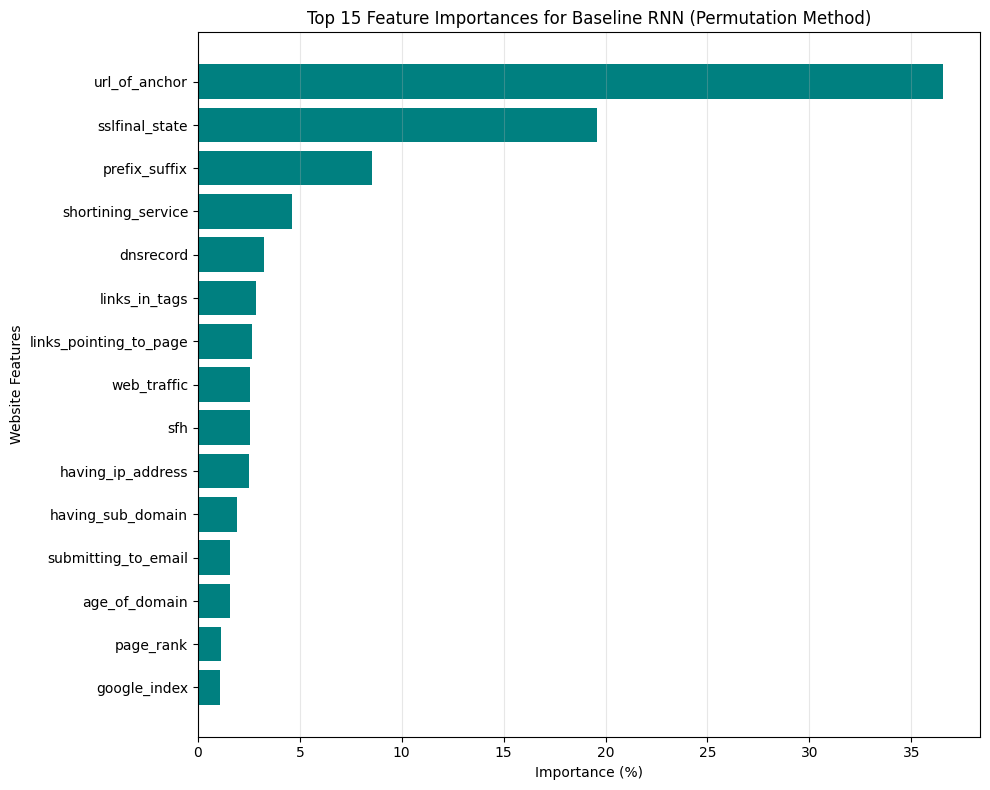

In [24]:
baseline_f1 = f1_score(y_test, y_pred)

feature_names = df.drop('result', axis=1).columns
importances = []

for i in range(X_test.shape[1]):
    X_test_shuffled = X_test.copy()
    np.random.shuffle(X_test_shuffled[:, i])

    # Reshaping the shuffled data for the RNN
    X_test_shuffled_rnn = X_test_shuffled.reshape((X_test_shuffled.shape[0], 1, X_test_shuffled.shape[1]))

    # Predicting with the corrupted feature
    y_pred_shuffled = (model.predict(X_test_shuffled_rnn, verbose=0).ravel() > 0.5).astype(int)

    # Calculateing drop in score
    shuffled_f1 = f1_score(y_test, y_pred_shuffled)
    drop_in_score = baseline_f1 - shuffled_f1
    importances.append(drop_in_score)


# Converting to arrays and process percentages
importances_array = np.array(importances)
importances_clipped = np.maximum(importances_array, 0)

total_importance = importances_clipped.sum()
if total_importance == 0:
    importance_percentages = importances_clipped * 0
else:
    importance_percentages = (importances_clipped / total_importance) * 100

# Creating DataFrame with the exact column names expected
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Raw F1 Drop': importances_array,
    'Importance (%)': importance_percentages
}).sort_values(by='Importance (%)', ascending=True)


print("\n--- Top 15 Feature Importances ---")
display_df = importance_df.tail(15).copy()
display_df['Importance (%)'] = display_df['Importance (%)'].apply(lambda x: f"{x:.2f}%")
print(display_df[::-1][['Feature', 'Importance (%)', 'Raw F1 Drop']].to_string(index=False))

# Plotting the Top 15 Most Important Features
plt.figure(figsize=(10, 8))
top_15 = importance_df.tail(15)

plt.barh(top_15['Feature'], top_15['Importance (%)'], color='teal')
plt.xlabel('Importance (%)')
plt.ylabel('Website Features')
plt.title('Top 15 Feature Importances for Baseline RNN (Permutation Method)')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [25]:
# Adding Results for comparison
model_results.append({
    'Model': 'RNN',
    'Accuracy': accuracy_RNN1,
    'Precision': precision_RNN1,
    'Recall': recall_RNN1,
    'F1 Score': f1_RNN1
})

roc_curves_results.append({
    'Model': 'RNN',
    'fpr': fpr,
    'tpr': tpr,
    'roc_auc': roc_auc
})

# Graph Neural Network Model Base line

Epoch  20 | Loss: 0.1688 | Val Loss: 0.2236 | Val Acc: 0.9174
Epoch  40 | Loss: 0.1441 | Val Loss: 0.1967 | Val Acc: 0.9252
Epoch  60 | Loss: 0.1278 | Val Loss: 0.1855 | Val Acc: 0.9264
Epoch  80 | Loss: 0.1185 | Val Loss: 0.1784 | Val Acc: 0.9306
Epoch 100 | Loss: 0.1074 | Val Loss: 0.1750 | Val Acc: 0.9294
Epoch 120 | Loss: 0.0990 | Val Loss: 0.1746 | Val Acc: 0.9300
Epoch 140 | Loss: 0.0967 | Val Loss: 0.1756 | Val Acc: 0.9258
Epoch 160 | Loss: 0.0946 | Val Loss: 0.1575 | Val Acc: 0.9349
Epoch 180 | Loss: 0.0886 | Val Loss: 0.1724 | Val Acc: 0.9264
Epoch 200 | Loss: 0.0899 | Val Loss: 0.1561 | Val Acc: 0.9409
GraphSAGE Accuracy:  0.9602
GraphSAGE Precision: 0.9602
GraphSAGE Recall:    0.9602
GraphSAGE F1 Score:  0.9602


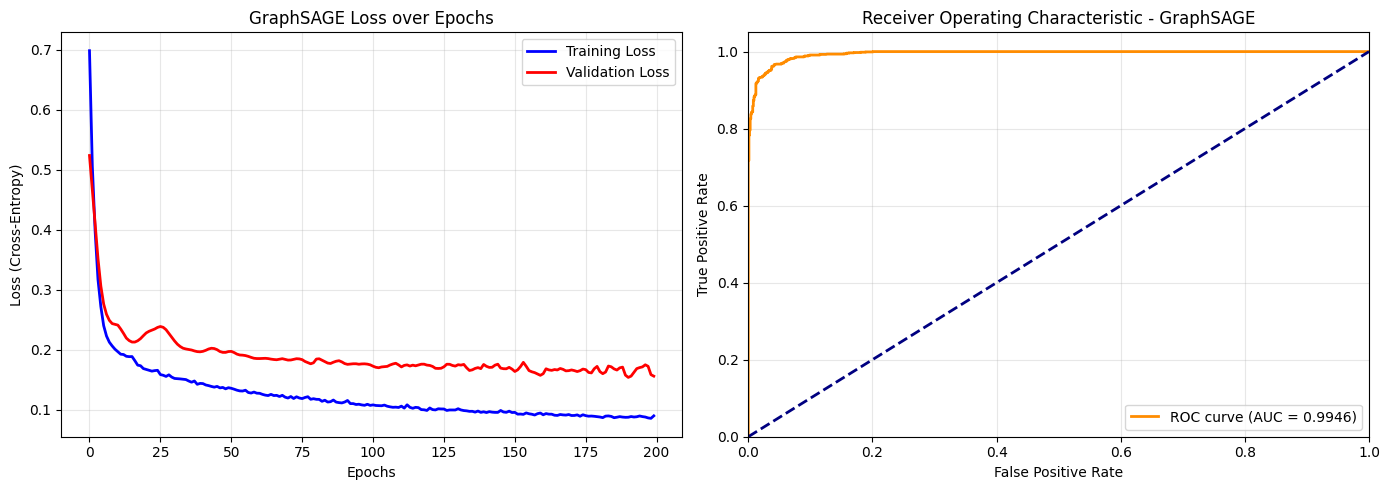

In [26]:
# ---- Rebuild full feature set (train+val+test) for graph construction ----
# Assumes X_train, X_val, X_test, y_train, y_val, y_test already exist from your split
X_all = np.vstack([X_train, X_val, X_test])
y_all = np.concatenate([y_train, y_val, y_test])

n_train, n_val, n_test = len(X_train), len(X_val), len(X_test)
n_total = n_train + n_val + n_test

# ---- Build k-NN similarity graph (k=10 is a reasonable default) ----
k = 10
adj = kneighbors_graph(X_all, n_neighbors=k, mode='connectivity', include_self=False)
adj = adj.tocoo()
edge_index = torch.tensor(np.vstack([adj.row, adj.col]), dtype=torch.long)

# Make undirected (PyG convention)
edge_index = torch.cat([edge_index, edge_index.flip(0)], dim=1)
edge_index = torch.unique(edge_index, dim=1)

# ---- Build masks matching your original train/val/test split ----
train_mask = torch.zeros(n_total, dtype=torch.bool)
val_mask = torch.zeros(n_total, dtype=torch.bool)
test_mask = torch.zeros(n_total, dtype=torch.bool)

train_mask[:n_train] = True
val_mask[n_train:n_train + n_val] = True
test_mask[n_train + n_val:] = True

# ---- Build PyG Data object ----
x = torch.tensor(X_all, dtype=torch.float)
y = torch.tensor(y_all, dtype=torch.long)

data = Data(x=x, edge_index=edge_index, y=y,
            train_mask=train_mask, val_mask=val_mask, test_mask=test_mask)

# ---- GraphSAGE model ----
class GraphSAGE(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return x

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GraphSAGE(in_channels=X_all.shape[1], hidden_channels=64, out_channels=2).to(device)
data = data.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

# ---- Training loop (now tracking loss/val_loss for plotting) ----
train_losses = []
val_losses = []

def train():
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

def compute_val_loss():
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        loss = F.cross_entropy(out[data.val_mask], data.y[data.val_mask])
    return loss.item()

def evaluate(mask):
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        pred = out.argmax(dim=1)
        proba = F.softmax(out, dim=1)
    return pred[mask].cpu().numpy(), proba[mask].cpu().numpy()

n_epochs = 200
for epoch in range(1, n_epochs + 1):
    loss = train()
    val_loss = compute_val_loss()
    train_losses.append(loss)
    val_losses.append(val_loss)
    if epoch % 20 == 0:
        val_pred, _ = evaluate(data.val_mask)
        val_acc = (val_pred == data.y[data.val_mask].cpu().numpy()).mean()
        print(f"Epoch {epoch:3d} | Loss: {loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

# ---- Final test evaluation ----
y_pred_gnn, y_score_gnn = evaluate(data.test_mask)
y_test_gnn = data.y[data.test_mask].cpu().numpy()

accuracy_gnn = (y_pred_gnn == y_test_gnn).mean()
precision_gnn = precision_score(y_test_gnn, y_pred_gnn, average='weighted', zero_division=0)
recall_gnn = recall_score(y_test_gnn, y_pred_gnn, average='weighted', zero_division=0)
f1_gnn = f1_score(y_test_gnn, y_pred_gnn, average='weighted', zero_division=0)

print(f"GraphSAGE Accuracy:  {accuracy_gnn:.4f}")
print(f"GraphSAGE Precision: {precision_gnn:.4f}")
print(f"GraphSAGE Recall:    {recall_gnn:.4f}")
print(f"GraphSAGE F1 Score:  {f1_gnn:.4f}")

# ---- Plots: Loss curve + ROC-AUC ----
plt.figure(figsize=(14, 5))

# Subplot 1: Loss over epochs
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss', color='blue', lw=2)
plt.plot(val_losses, label='Validation Loss', color='red', lw=2)
plt.title('GraphSAGE Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss (Cross-Entropy)')
plt.legend()
plt.grid(alpha=0.3)

# Subplot 2: ROC-AUC Curve
plt.subplot(1, 2, 2)
fpr, tpr, thresholds = roc_curve(y_test_gnn, y_score_gnn[:, 1])
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - GraphSAGE')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [27]:
# Adding Results for comparison
model_results.append({
    'Model': 'GNN',
    'Accuracy': accuracy_gnn,
    'Precision': precision_gnn,
    'Recall': recall_gnn,
    'F1 Score': f1_gnn
})

roc_curves_results.append({
    'Model': 'GNN',
    'fpr': fpr,
    'tpr': tpr,
    'roc_auc': roc_auc
})

        Model  Accuracy  Precision   Recall  F1 Score
Random Forest  0.962025   0.962265 0.962025  0.961957
      XGBoost  0.963231   0.961497 0.972944  0.967187
          RNN  0.951153   0.945282 0.968318  0.956661
          GNN  0.960199   0.960190 0.960199  0.960182


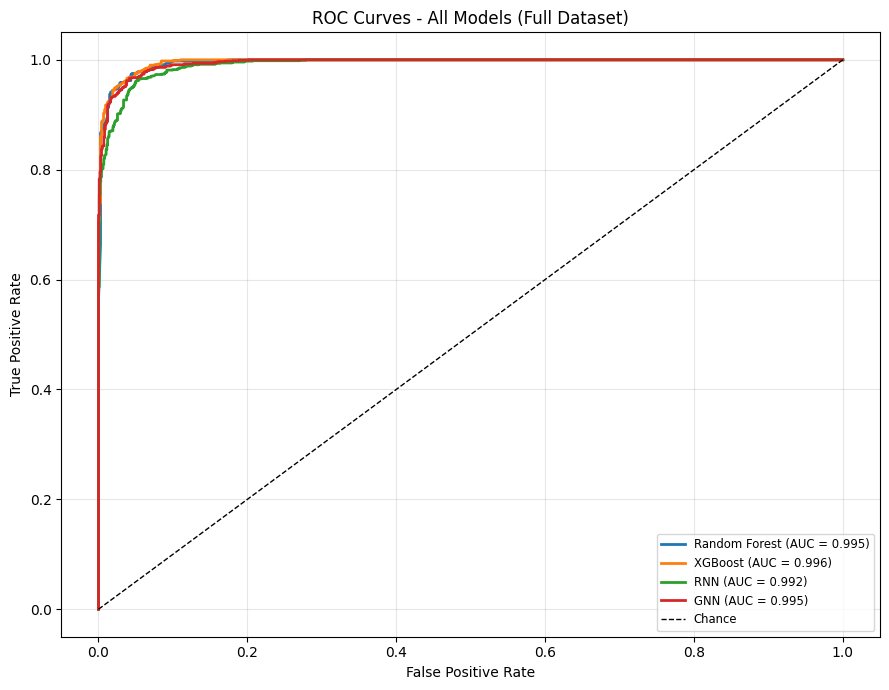

In [28]:
# Displaying results with full dataset
summary_df = pd.DataFrame(model_results)
summary_df = summary_df[[
    "Model", "Accuracy", "Precision", "Recall", "F1 Score"
]]
summary_df.index = np.arange(1, len(summary_df) + 1)
print(summary_df.to_string(index=False))

# Plotting ROC Curve
plt.figure(figsize=(9, 7))
for item in roc_curves_results:
    plt.plot(item["fpr"], item["tpr"], lw=2, label=f'{item["Model"]} (AUC = {item["roc_auc"]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Models (Full Dataset)')
plt.legend(loc='lower right', fontsize='small')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Analysis:**

[insert analysis here]

## Model #2: TBA 👀

# Here is the code that will now drop SSl certificate and url_of_anchor columns and re-run the models to see how the performance compares.

In [29]:
X = df.drop(['result', 'sslfinal_state', 'url_of_anchor'], axis=1).values
y = df['result'].map({-1: 0, 1: 1}).values

# Step 1: split off 70% train, 30% remaining
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=6704
)

# Step 2: split the remaining 30% evenly into 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=1996
)

print(f"Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}")


Train: (7738, 28)  Val: (1658, 28)  Test: (1659, 28)


# Random Forrest Rerun without SSL column and URL of Anchor

### Training new RF model and getting Validation accuracy

# RF model with reduced features

In [30]:
rf_classifier = RandomForestClassifier(
    n_estimators=100,      # Number of decision trees
    max_depth=None,        # Trees grow until leaves are pure
    random_state=42,       # Ensures reproducible splits and results
    n_jobs=-1              # Use all available CPU cores for parallel processing
)

rf_classifier.fit(X_train, y_train)
val_preds = rf_classifier.predict(X_val)
val_accuracy = accuracy_score(y_val, val_preds)
print(f"Validation Accuracy: {val_accuracy:.4f}")

y_pred = rf_classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)



Validation Accuracy: 0.9240


### Running RF model on test set with metrics and feature importance

Accuracy:  0.9186
Precision: 0.9186
Recall:    0.9186
F1 Score:  0.9186


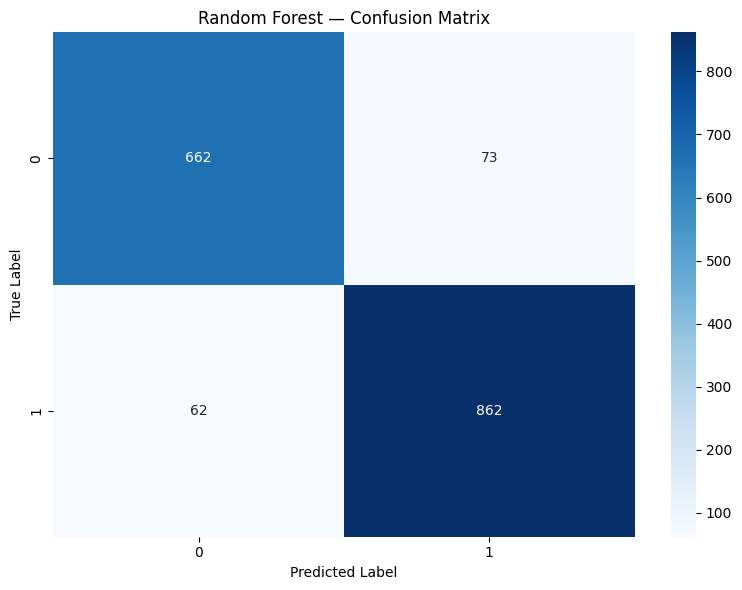

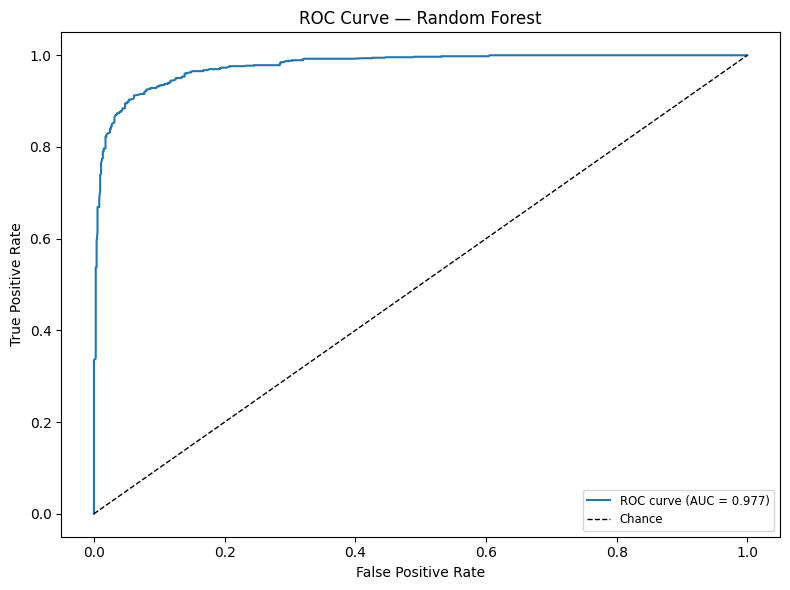

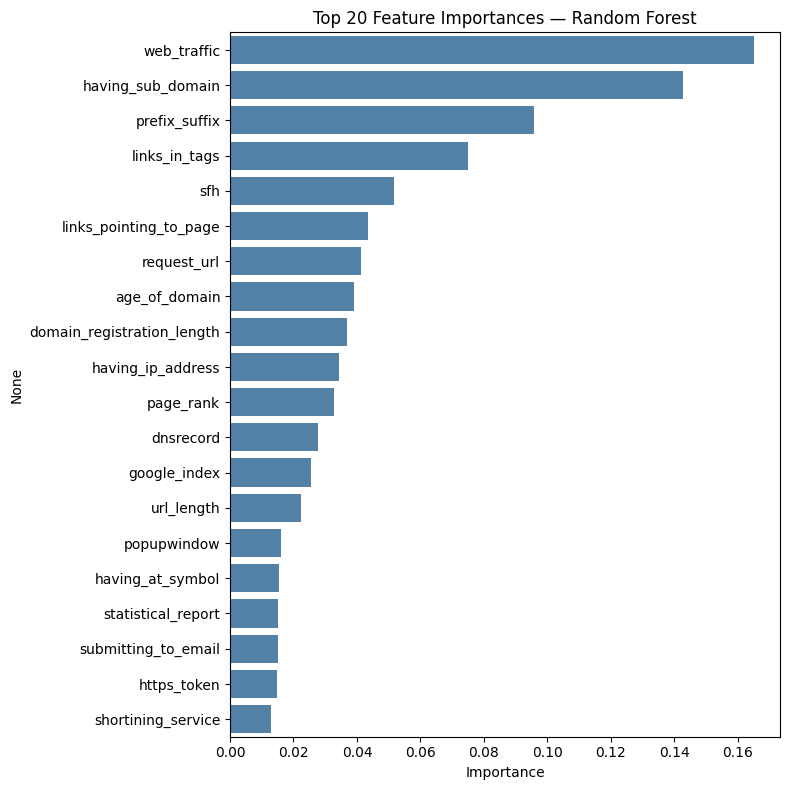

In [31]:
# ---- Basic metrics ----
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

classes = rf_classifier.classes_
n_classes = len(classes)

# ---- Confusion Matrix ----
cm = confusion_matrix(y_test, y_pred, labels=classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.show()

# ---- ROC Curve(s) ----
y_score = rf_classifier.predict_proba(X_test)

plt.figure(figsize=(8, 6))

if n_classes == 2:
    # Binary case
    fpr, tpr, _ = roc_curve(y_test, y_score[:, 1], pos_label=classes[1])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
else:
    # Multi-class: one-vs-rest
    y_test_bin = label_binarize(y_test, classes=classes)
    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{cls} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Random Forest')
plt.legend(loc='lower right', fontsize='small')
plt.tight_layout()
plt.show()

# ---- Feature Importance ----
importances = pd.Series(rf_classifier.feature_importances_, index=df.drop(['result', 'sslfinal_state', 'url_of_anchor'], axis=1).columns)
importances = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(8, 8))
sns.barplot(x=importances.values, y=importances.index, color='steelblue')
plt.xlabel('Importance')
plt.title('Top 20 Feature Importances — Random Forest')
plt.tight_layout()
plt.show()

In [32]:
model_results.append({
    'Model': 'Random Forest (Reduced Features)',
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1 Score': f1
})

roc_curves_results.append({
    'Model': 'Random Forest (Reduced Features)',
    'fpr': fpr,
    'tpr': tpr,
    'roc_auc': roc_auc
})

# XGBoost Rerun without SSL and url_of_anchor columns

## Data preparation for reduced feature set

In [33]:
# XGBoost Rerun — Data Prep (SSL + url_of_anchor dropped)
# Self-contained: rebuilds the reduced feature set with the SAME seeds used
# everywhere else (6704 / 1996), so this is directly comparable both to the
# full-feature XGBoost above and to the Random Forest rerun.

DROPPED_FEATURES = ['sslfinal_state', 'url_of_anchor']

X = df.drop(['result'] + DROPPED_FEATURES, axis=1).values
y = df['result'].map({-1: 0, 1: 1}).values          # 1 = phishing, 0 = safe
feature_names_reduced = df.drop(['result'] + DROPPED_FEATURES, axis=1).columns

# Step 1: 70% train, 30% remaining
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=6704
)

# Step 2: split the remaining 30% evenly into 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=1996
)

print(f"Dropped features: {DROPPED_FEATURES}")
print(f"Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}")

Dropped features: ['sslfinal_state', 'url_of_anchor']
Train: (7738, 28)  Val: (1658, 28)  Test: (1659, 28)


## Training the new XGBoost model and getting validation accuracy

In [34]:
# Training XGBoost on the reduced feature set
# NOTE: n_estimators is raised to 1500 here (vs 500 in the full-feature run).
# Without its two strongest predictors the model needs more boosting rounds to
# converge; at 500 it stopped at iteration 492, meaning the budget — not the
# validation loss — was the binding constraint. Early stopping now settles
# around iteration ~620 on its own.
xgb_reduced = XGBClassifier(
    n_estimators=1500,           # Upper bound on boosting rounds
    learning_rate=0.1,           # Step size shrinkage
    max_depth=6,                 # Max tree depth
    subsample=0.8,               # Row sampling per tree
    colsample_bytree=0.8,        # Feature sampling per tree
    reg_lambda=1.0,              # L2 regularization on leaf weights
    objective='binary:logistic',
    eval_metric='logloss',
    early_stopping_rounds=25,
    random_state=42,
    n_jobs=-1
)

xgb_reduced.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print(f"Best iteration (early stopping): {xgb_reduced.best_iteration}")

val_preds = xgb_reduced.predict(X_val)
val_accuracy_reduced = accuracy_score(y_val, val_preds)
print(f"Validation Accuracy: {val_accuracy_reduced:.4f}")

# Test-set predictions
y_pred_prob_xgb_reduced = xgb_reduced.predict_proba(X_test)[:, 1]
y_pred_xgb_reduced = (y_pred_prob_xgb_reduced >= 0.5).astype(int)

Best iteration (early stopping): 624
Validation Accuracy: 0.9264


## Metrics


--- XGBoost Metrics, Reduced Features (Test Set) ---
Accuracy:  0.9210
Precision: 0.9286
Recall:    0.9297
F1 Score:  0.9292
ROC AUC:   0.9825

--- Confusion Matrix Breakdown ---
True Negatives (TN):  669 (Actually Safe, Predicted Safe)
False Positives (FP): 66 (Actually Safe, Predicted Phishing - False Alarm)
False Negatives (FN): 65 (Actually Phishing, Predicted Safe - Missed Threat)
True Positives (TP):  859 (Actually Phishing, Predicted Phishing)

Specificity (safe sites correctly cleared): 0.9102


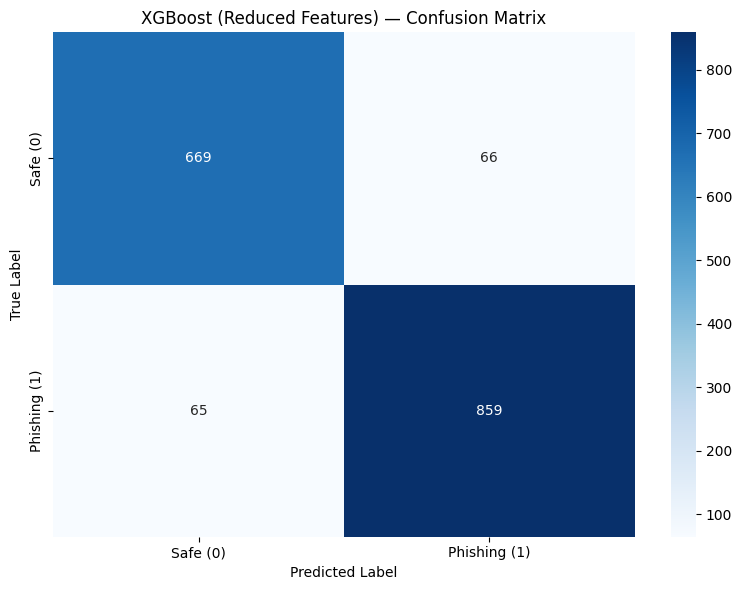

In [35]:
# Storing results for comparing models
accuracy_XGB_reduced  = accuracy_score(y_test, y_pred_xgb_reduced)
precision_XGB_reduced = precision_score(y_test, y_pred_xgb_reduced)
recall_XGB_reduced    = recall_score(y_test, y_pred_xgb_reduced)
f1_XGB_reduced        = f1_score(y_test, y_pred_xgb_reduced)
roc_auc_XGB_reduced   = roc_auc_score(y_test, y_pred_prob_xgb_reduced)

print("\n--- XGBoost Metrics, Reduced Features (Test Set) ---")
print(f"Accuracy:  {accuracy_XGB_reduced:.4f}")
print(f"Precision: {precision_XGB_reduced:.4f}")
print(f"Recall:    {recall_XGB_reduced:.4f}")
print(f"F1 Score:  {f1_XGB_reduced:.4f}")
print(f"ROC AUC:   {roc_auc_XGB_reduced:.4f}")

# ---- Confusion Matrix ----
cm = confusion_matrix(y_test, y_pred_xgb_reduced)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)

print("\n--- Confusion Matrix Breakdown ---")
print(f"True Negatives (TN):  {tn} (Actually Safe, Predicted Safe)")
print(f"False Positives (FP): {fp} (Actually Safe, Predicted Phishing - False Alarm)")
print(f"False Negatives (FN): {fn} (Actually Phishing, Predicted Safe - Missed Threat)")
print(f"True Positives (TP):  {tp} (Actually Phishing, Predicted Phishing)")
print(f"\nSpecificity (safe sites correctly cleared): {specificity:.4f}")

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Safe (0)', 'Phishing (1)'],
            yticklabels=['Safe (0)', 'Phishing (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('XGBoost (Reduced Features) — Confusion Matrix')
plt.tight_layout()
plt.show()

## ROC AUC Curve

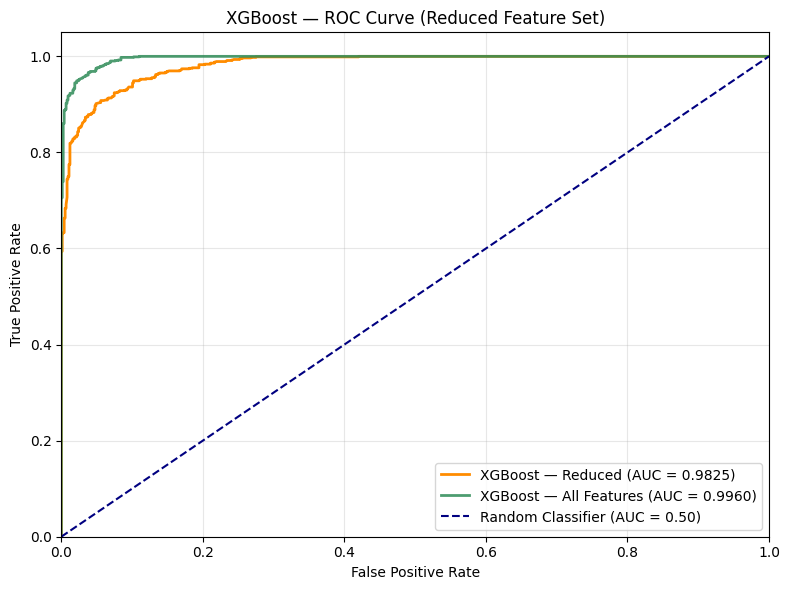

ROC AUC: 0.9825


In [36]:
# ---- ROC Curve ----
fpr_reduced, tpr_reduced, thresholds = roc_curve(y_test, y_pred_prob_xgb_reduced)
roc_auc_reduced = auc(fpr_reduced, tpr_reduced)

plt.figure(figsize=(8, 6))
plt.plot(fpr_reduced, tpr_reduced, color='darkorange', lw=2,
         label=f'XGBoost — Reduced (AUC = {roc_auc_reduced:.4f})')

# Overlay the full-feature curve if the earlier XGBoost section has been run
if 'y_pred_prob_xgb' in globals():
    try:
        fpr_full, tpr_full, _ = roc_curve(y_test, y_pred_prob_xgb)
        plt.plot(fpr_full, tpr_full, color='seagreen', lw=2, alpha=0.85,
                 label=f'XGBoost — All Features (AUC = {auc(fpr_full, tpr_full):.4f})')
    except ValueError:
        pass  # test split changed since that model ran; skip the overlay

plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--',
         label='Random Classifier (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost — ROC Curve (Reduced Feature Set)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"ROC AUC: {roc_auc_reduced:.4f}")

## Feature Importance

--- Top 10 Features (Reduced Set) ---
                 Feature  Importance  Importance %
           prefix_suffix    0.505821     50.582092
             web_traffic    0.039569      3.956879
       having_sub_domain    0.034232      3.423217
      shortining_service    0.028399      2.839888
double_slash_redirecting    0.027922      2.792157
                     sfh    0.023963      2.396277
             popupwindow    0.021199      2.119950
               page_rank    0.018804      1.880375
                 favicon    0.018286      1.828639
            on_mouseover    0.017874      1.787397

Top 3 features account for 58.0% of total gain.


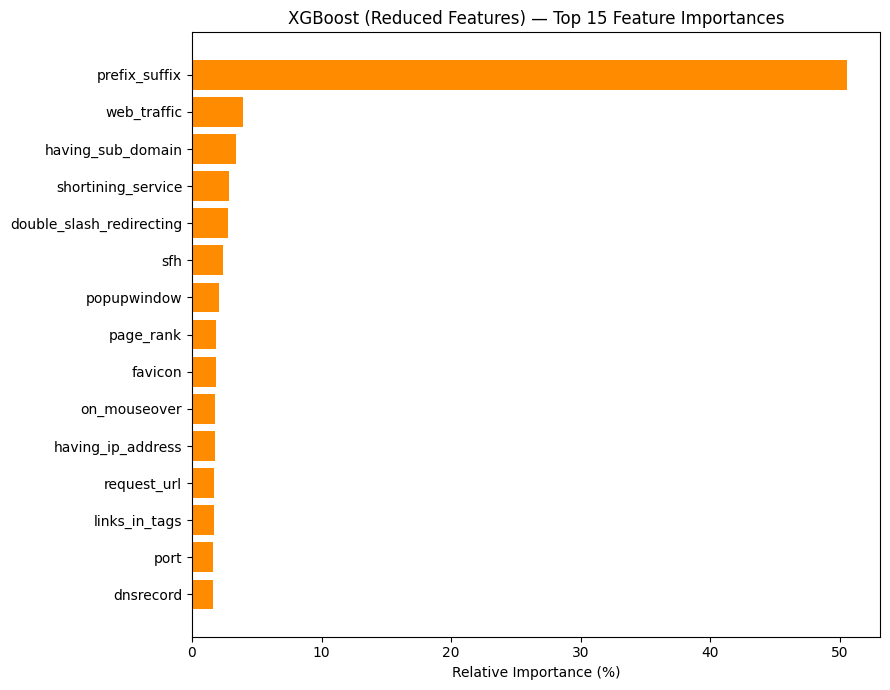

In [37]:
# ---- Feature Importance (gain-based) ----
importance_df_reduced = pd.DataFrame({
    'Feature': feature_names_reduced,
    'Importance': xgb_reduced.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

importance_df_reduced['Importance %'] = (
    importance_df_reduced['Importance'] / importance_df_reduced['Importance'].sum() * 100
)

print("--- Top 10 Features (Reduced Set) ---")
print(importance_df_reduced.head(10).to_string(index=False))

top3 = importance_df_reduced.head(3)['Importance %'].sum()
print(f"\nTop 3 features account for {top3:.1f}% of total gain.")

top_n = importance_df_reduced.head(15).iloc[::-1]
plt.figure(figsize=(9, 7))
plt.barh(top_n['Feature'], top_n['Importance %'], color='darkorange')
plt.xlabel('Relative Importance (%)')
plt.title('XGBoost (Reduced Features) — Top 15 Feature Importances')
plt.tight_layout()
plt.show()

## Comparison: full vs reduced feature set

In [38]:
# ---- Side-by-side comparison: full vs reduced feature set ----
# Requires the earlier full-feature XGBoost section to have been run.
if 'accuracy_XGB' in globals():
    comparison = pd.DataFrame({
        'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC'],
        'All Features': [accuracy_XGB, precision_XGB, recall_XGB, f1_XGB, roc_auc_XGB],
        'SSL + Anchor Dropped': [accuracy_XGB_reduced, precision_XGB_reduced,
                                 recall_XGB_reduced, f1_XGB_reduced, roc_auc_XGB_reduced]
    })
    comparison['Change'] = comparison['SSL + Anchor Dropped'] - comparison['All Features']
    comparison['Change (pp)'] = comparison['Change'] * 100

    print("--- XGBoost: Impact of Dropping sslfinal_state and url_of_anchor ---")
    print(comparison.to_string(index=False,
          formatters={'All Features': '{:.4f}'.format,
                      'SSL + Anchor Dropped': '{:.4f}'.format,
                      'Change': '{:+.4f}'.format,
                      'Change (pp)': '{:+.2f}'.format}))
else:
    print("Run the full-feature XGBoost section first to enable this comparison.")

--- XGBoost: Impact of Dropping sslfinal_state and url_of_anchor ---
   Metric All Features SSL + Anchor Dropped  Change Change (pp)
 Accuracy       0.9632               0.9210 -0.0422       -4.22
Precision       0.9615               0.9286 -0.0328       -3.28
   Recall       0.9729               0.9297 -0.0433       -4.33
 F1 Score       0.9672               0.9292 -0.0380       -3.80
  ROC AUC       0.9960               0.9825 -0.0135       -1.35


In [39]:
model_results.append({
    'Model': 'XGBoost (Reduced Features)',
    'Accuracy': accuracy_XGB_reduced,
    'Precision': precision_XGB_reduced,
    'Recall': recall_XGB_reduced,
    'F1 Score': f1_XGB_reduced
})

roc_curves_results.append({
    'Model': 'XGBoost (Reduced Features)',
    'fpr': fpr_reduced,
    'tpr': tpr_reduced,
    'roc_auc': roc_auc_reduced
})

### **Analysis:**

# GNN without SSL column

Epoch  20 | Loss: 0.3865 | Val Loss: 0.3944 | Val Acc: 0.8366
Epoch  40 | Loss: 0.3357 | Val Loss: 0.3582 | Val Acc: 0.8281
Epoch  60 | Loss: 0.3109 | Val Loss: 0.3361 | Val Acc: 0.8414
Epoch  80 | Loss: 0.2877 | Val Loss: 0.3155 | Val Acc: 0.8546
Epoch 100 | Loss: 0.2778 | Val Loss: 0.3079 | Val Acc: 0.8595
Epoch 120 | Loss: 0.2679 | Val Loss: 0.2972 | Val Acc: 0.8601
Epoch 140 | Loss: 0.2620 | Val Loss: 0.2916 | Val Acc: 0.8667
Epoch 160 | Loss: 0.2541 | Val Loss: 0.2846 | Val Acc: 0.8649
Epoch 180 | Loss: 0.2503 | Val Loss: 0.2776 | Val Acc: 0.8679
Epoch 200 | Loss: 0.2487 | Val Loss: 0.2720 | Val Acc: 0.8715
GraphSAGE Accuracy:  0.8837
GraphSAGE Precision: 0.8844
GraphSAGE Recall:    0.8837
GraphSAGE F1 Score:  0.8838


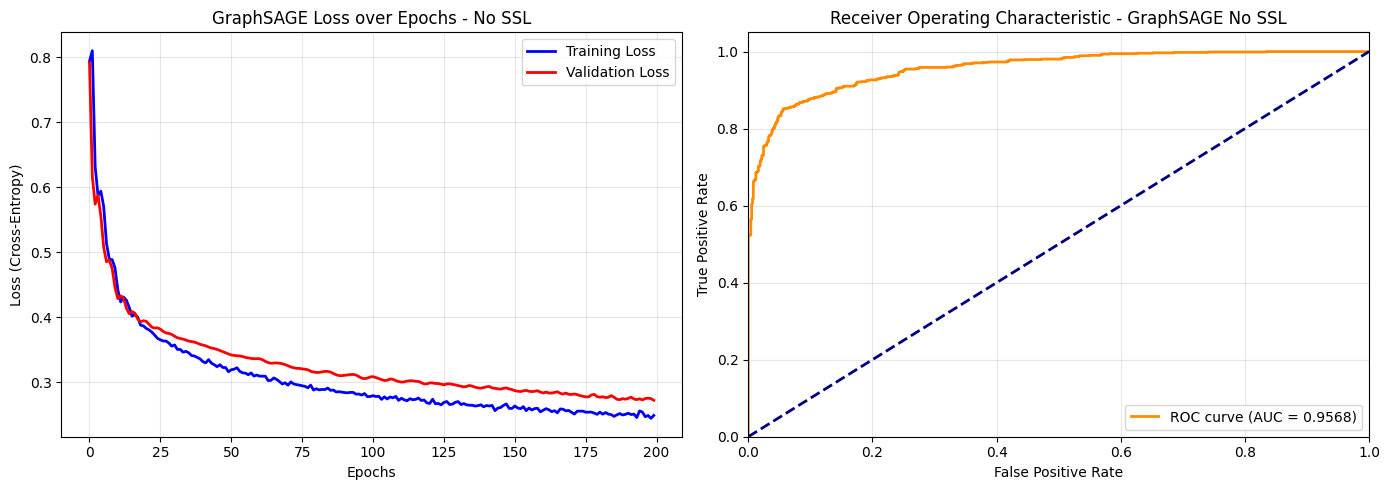

In [40]:
# ---- Rebuild full feature set (train+val+test) for graph construction ----
# Assumes X_train, X_val, X_test, y_train, y_val, y_test already exist from your split
X_all = np.vstack([X_train, X_val, X_test])
y_all = np.concatenate([y_train, y_val, y_test])

n_train, n_val, n_test = len(X_train), len(X_val), len(X_test)
n_total = n_train + n_val + n_test

# ---- Build k-NN similarity graph (k=10 is a reasonable default) ----
k = 10
adj = kneighbors_graph(X_all, n_neighbors=k, mode='connectivity', include_self=False)
adj = adj.tocoo()
edge_index = torch.tensor(np.vstack([adj.row, adj.col]), dtype=torch.long)

# Make undirected (PyG convention)
edge_index = torch.cat([edge_index, edge_index.flip(0)], dim=1)
edge_index = torch.unique(edge_index, dim=1)

# ---- Build masks matching your original train/val/test split ----
train_mask = torch.zeros(n_total, dtype=torch.bool)
val_mask = torch.zeros(n_total, dtype=torch.bool)
test_mask = torch.zeros(n_total, dtype=torch.bool)

train_mask[:n_train] = True
val_mask[n_train:n_train + n_val] = True
test_mask[n_train + n_val:] = True

# ---- Build PyG Data object ----
x = torch.tensor(X_all, dtype=torch.float)
y = torch.tensor(y_all, dtype=torch.long)

data = Data(x=x, edge_index=edge_index, y=y,
            train_mask=train_mask, val_mask=val_mask, test_mask=test_mask)

# ---- GraphSAGE model ----
class GraphSAGE(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return x

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GraphSAGE(in_channels=X_all.shape[1], hidden_channels=64, out_channels=2).to(device)
data = data.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

# ---- Training loop (now tracking loss/val_loss for plotting) ----
train_losses = []
val_losses = []

def train():
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

def compute_val_loss():
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        loss = F.cross_entropy(out[data.val_mask], data.y[data.val_mask])
    return loss.item()

def evaluate(mask):
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        pred = out.argmax(dim=1)
        proba = F.softmax(out, dim=1)
    return pred[mask].cpu().numpy(), proba[mask].cpu().numpy()

n_epochs = 200
for epoch in range(1, n_epochs + 1):
    loss = train()
    val_loss = compute_val_loss()
    train_losses.append(loss)
    val_losses.append(val_loss)
    if epoch % 20 == 0:
        val_pred, _ = evaluate(data.val_mask)
        val_acc = (val_pred == data.y[data.val_mask].cpu().numpy()).mean()
        print(f"Epoch {epoch:3d} | Loss: {loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

# ---- Final test evaluation ----
y_pred_gnn, y_score_gnn = evaluate(data.test_mask)
y_test_gnn = data.y[data.test_mask].cpu().numpy()

accuracy_gnn = (y_pred_gnn == y_test_gnn).mean()
precision_gnn = precision_score(y_test_gnn, y_pred_gnn, average='weighted', zero_division=0)
recall_gnn = recall_score(y_test_gnn, y_pred_gnn, average='weighted', zero_division=0)
f1_gnn = f1_score(y_test_gnn, y_pred_gnn, average='weighted', zero_division=0)

print(f"GraphSAGE Accuracy:  {accuracy_gnn:.4f}")
print(f"GraphSAGE Precision: {precision_gnn:.4f}")
print(f"GraphSAGE Recall:    {recall_gnn:.4f}")
print(f"GraphSAGE F1 Score:  {f1_gnn:.4f}")

# ---- Plots: Loss curve + ROC-AUC ----
plt.figure(figsize=(14, 5))

# Subplot 1: Loss over epochs
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss', color='blue', lw=2)
plt.plot(val_losses, label='Validation Loss', color='red', lw=2)
plt.title('GraphSAGE Loss over Epochs - No SSL')
plt.xlabel('Epochs')
plt.ylabel('Loss (Cross-Entropy)')
plt.legend()
plt.grid(alpha=0.3)

# Subplot 2: ROC-AUC Curve
plt.subplot(1, 2, 2)
fpr, tpr, thresholds = roc_curve(y_test_gnn, y_score_gnn[:, 1])
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - GraphSAGE No SSL')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [41]:
model_results.append({
    'Model': 'GNN (Reduced Features)',
    'Accuracy': accuracy_gnn,
    'Precision': precision_gnn,
    'Recall': recall_gnn,
    'F1 Score': f1_gnn
})

roc_curves_results.append({
    'Model': 'GNN (Reduced Features)',
    'fpr': fpr,
    'tpr': tpr,
    'roc_auc': roc_auc
})

### Experiment that keeps dropping the most important feature until N remains to see what values actually matter in threat detection

Features: 28 | Val F1: 0.9239
  Removing top feature: web_traffic (importance: 0.1651)
Features: 27 | Val F1: 0.8857
  Removing top feature: having_sub_domain (importance: 0.1657)
Features: 26 | Val F1: 0.8562
  Removing top feature: prefix_suffix (importance: 0.1374)
Features: 25 | Val F1: 0.8300
  Removing top feature: links_in_tags (importance: 0.1256)
Features: 24 | Val F1: 0.8035
  Removing top feature: sfh (importance: 0.1025)
Features: 23 | Val F1: 0.7820
  Removing top feature: links_pointing_to_page (importance: 0.1015)
Features: 22 | Val F1: 0.7538
  Removing top feature: request_url (importance: 0.0978)
Features: 21 | Val F1: 0.7560
  Removing top feature: domain_registration_length (importance: 0.1084)
Features: 20 | Val F1: 0.7276
  Removing top feature: having_ip_address (importance: 0.0960)
Features: 19 | Val F1: 0.6948
  Removing top feature: page_rank (importance: 0.1108)
Features: 18 | Val F1: 0.6903
  Removing top feature: dnsrecord (importance: 0.0902)
Features: 17 

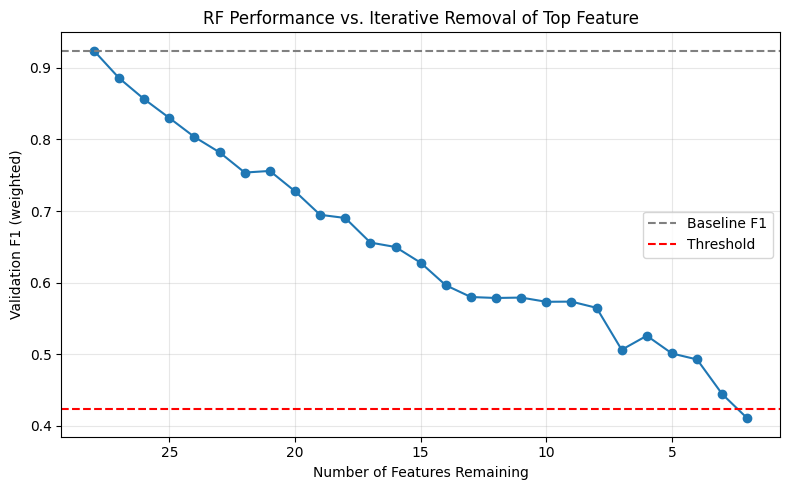

Removal order (RF): ['web_traffic', 'having_sub_domain', 'prefix_suffix', 'links_in_tags', 'sfh', 'links_pointing_to_page', 'request_url', 'domain_registration_length', 'having_ip_address', 'page_rank', 'dnsrecord', 'google_index', 'url_length', 'age_of_domain', 'shortining_service', 'popupwindow', 'on_mouseover', 'favicon', 'port', 'iframe', 'submitting_to_email', 'statistical_report', 'redirect', 'rightclick', 'abnormal_url', 'having_at_symbol']


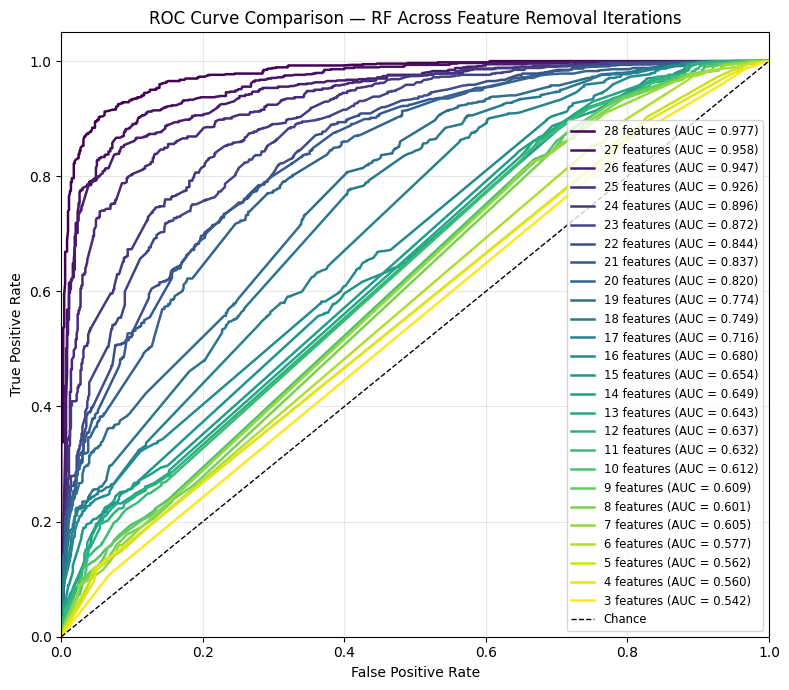

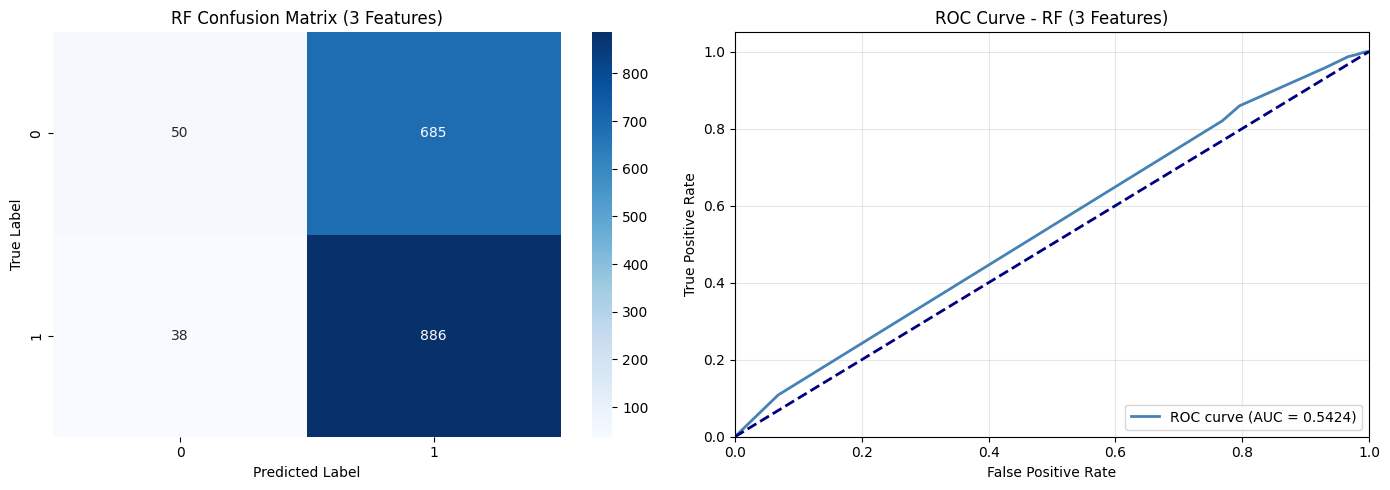

In [43]:
import matplotlib.cm as cm

# ---- Setup ----
feature_names = list(df.drop(['result', 'sslfinal_state', 'url_of_anchor'], axis=1).columns)
X_train_cur = X_train.copy()
X_val_cur = X_val.copy()
X_test_cur = X_test.copy()
current_features = feature_names.copy()

threshold = 0.5  # stop once val F1 drops more than 2 points below baseline — adjust as needed
baseline_score = None
results = []

# ---- Lists to capture removal order for reuse (e.g. in the GNN experiment) ----
removed_features_order = []
removed_importances = []

# ---- Track the last model/data that stayed above threshold ----
final_rf = None
final_X_test_cur = None
final_features = None

# ---- Track ROC data for every iteration ----
roc_curves = []  # each entry: {'n_features': int, 'fpr': array, 'tpr': array, 'auc': float}

# ---- Iterative removal loop ----
while len(current_features) > 1:
    rf = RandomForestClassifier(random_state=42)
    rf.fit(X_train_cur, y_train)
    y_val_pred = rf.predict(X_val_cur)
    val_f1 = f1_score(y_val, y_val_pred, average='weighted', zero_division=0)

    if baseline_score is None:
        baseline_score = val_f1

    print(f"Features: {len(current_features):2d} | Val F1: {val_f1:.4f}")

    if val_f1 < baseline_score - threshold:
        print(f"Stopping: Val F1 ({val_f1:.4f}) dropped below threshold "
              f"({baseline_score - threshold:.4f})")
        results.append({
            'n_features': len(current_features),
            'removed_feature': None,
            'val_f1': val_f1
        })
        break

    # keep the last model that stayed above threshold
    final_rf = rf
    final_X_test_cur = X_test_cur.copy()
    final_features = current_features.copy()

    # ---- Compute test-set ROC for this iteration's model ----
    y_score_iter = rf.predict_proba(X_test_cur)
    fpr_iter, tpr_iter, _ = roc_curve(y_test, y_score_iter[:, 1])
    auc_iter = auc(fpr_iter, tpr_iter)
    roc_curves.append({
        'n_features': len(current_features),
        'fpr': fpr_iter,
        'tpr': tpr_iter,
        'auc': auc_iter
    })

    importances = pd.Series(rf.feature_importances_, index=current_features)
    top_feature = importances.idxmax()
    top_idx = current_features.index(top_feature)

    print(f"  Removing top feature: {top_feature} (importance: {importances.max():.4f})")

    results.append({
        'n_features': len(current_features),
        'removed_feature': top_feature,
        'val_f1': val_f1
    })

    # ---- Save the removed feature and its importance for reuse ----
    removed_features_order.append(top_feature)
    removed_importances.append(importances.max())

    X_train_cur = np.delete(X_train_cur, top_idx, axis=1)
    X_val_cur = np.delete(X_val_cur, top_idx, axis=1)
    X_test_cur = np.delete(X_test_cur, top_idx, axis=1)
    current_features.pop(top_idx)

results_df = pd.DataFrame(results)
print(results_df)

# ---- Plot performance vs. number of features ----
plt.figure(figsize=(8, 5))
plt.plot(results_df['n_features'], results_df['val_f1'], marker='o')
plt.gca().invert_xaxis()  # so it reads left-to-right as features are removed
plt.axhline(baseline_score, color='gray', linestyle='--', label='Baseline F1')
plt.axhline(baseline_score - threshold, color='red', linestyle='--', label='Threshold')
plt.xlabel('Number of Features Remaining')
plt.ylabel('Validation F1 (weighted)')
plt.title('RF Performance vs. Iterative Removal of Top Feature')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Removal order (RF):", removed_features_order)

# ---- Combined ROC comparison across all iterations ----
plt.figure(figsize=(8, 7))
colors = cm.viridis(np.linspace(0, 1, len(roc_curves)))

for entry, color in zip(roc_curves, colors):
    plt.plot(entry['fpr'], entry['tpr'], color=color, lw=1.8,
             label=f"{entry['n_features']} features (AUC = {entry['auc']:.3f})")

plt.plot([0, 1], [0, 1], color='black', lw=1, linestyle='--', label='Chance')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison — RF Across Feature Removal Iterations')
plt.legend(loc='lower right', fontsize='small')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ---- Confusion Matrix + ROC-AUC for the final surviving model ----
y_pred_final = final_rf.predict(final_X_test_cur)
y_score_final = final_rf.predict_proba(final_X_test_cur)

plt.figure(figsize=(14, 5))

# Subplot 1: Confusion Matrix
plt.subplot(1, 2, 1)
cm_final = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'RF Confusion Matrix ({len(final_features)} Features)')

# Subplot 2: ROC-AUC Curve (final model only, for reference)
plt.subplot(1, 2, 2)
fpr, tpr, thresholds = roc_curve(y_test, y_score_final[:, 1])
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve - RF ({len(final_features)} Features)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---

# Model Functions - with updated data
 - using 70/15/15 split instead of 80/20
 - testing best hyperparameters
 - uses Either RNN or GRU


In [45]:
# Set device (MPS for Apple Silicon, CUDA for Nvidia, otherwise CPU)
device = torch.device('cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))
print(f'Using device: {device}')

Using device: cuda


## Scaling

In [46]:
# Scaling the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Reshaping and converting to PyTorch tensors
X_train_t = torch.FloatTensor(X_train_scaled).unsqueeze(1)
X_val_t = torch.FloatTensor(X_val_scaled).unsqueeze(1)
X_test_t = torch.FloatTensor(X_test_scaled).unsqueeze(1)

y_train_t = torch.FloatTensor(y_train).unsqueeze(1)
y_val_t = torch.FloatTensor(y_val).unsqueeze(1)
y_test_t = torch.FloatTensor(y_test).unsqueeze(1)

batch_size = 32
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=batch_size, shuffle=False)

## Building Model

In [47]:
# Building model
class PhishingModel(nn.Module):
    def __init__(self, input_size, hidden_size=32, dropout_rate=0.2, cell_type='rnn', activation='relu'):
        super().__init__()
        self.cell_type = cell_type.lower()

        if self.cell_type == 'gru':
            self.rnn = nn.GRU(input_size=input_size, hidden_size=hidden_size, batch_first=True)
        else:
            self.rnn = nn.RNN(input_size=input_size, hidden_size=hidden_size, batch_first=True, nonlinearity='relu')

        self.dropout = nn.Dropout(dropout_rate)
        self.fc1 = nn.Linear(hidden_size, 16)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(16, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = out[:, -1, :]

        out = self.dropout(out)
        out = self.relu(self.fc1(out))
        out = self.fc2(out)
        return out

## Setting CV and Grid

In [48]:
# Defining the Hyperparameter Grid
param_grid = {
    'hidden_size': [16, 32],
    'dropout_rate': [0.2, 0.4],
    'lr': [0.001, 0.005],
    'activation': ['relu', 'tanh']
}
grid = list(ParameterGrid(param_grid))

# Setting K-Fold Cross Validation
k_folds = 3
kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)
batch_size = 32
epochs = 15

best_score = 0
best_params = None
best_history = None  # To store the loss curves of the best model
results = []

print(f"Total hyperparameter combinations to test: {len(grid)}\n")

Total hyperparameter combinations to test: 16



## Cross-Validation

In [49]:
# FUNCTION: Grid Search CV
def run_architecture_search(target_cell_type):
    print(f"\n{'='*50}")
    print(f"STARTING TUNING FOR ARCHITECTURE: {target_cell_type.upper()}")
    print(f"{'='*50}\n")

    best_score = 0
    best_params = None
    best_history = None
    results = []

    for i, params in enumerate(grid):
        print(f"--- Testing {target_cell_type.upper()} Combination {i+1}/{len(grid)} ---")
        print(params)

        # Tracking loss for this specific combination
        history = {'train_loss': [], 'val_loss': []}

        # Initializing model
        model = PhishingModel(
            input_size=X_train_t.shape[2],
            hidden_size=params['hidden_size'],
            dropout_rate=params['dropout_rate'],
            cell_type=target_cell_type,
            activation=params['activation']
        ).to(device)

        optimizer = optim.Adam(model.parameters(), lr=params['lr'])
        criterion = nn.BCEWithLogitsLoss()

        # Loop for Training and Validating model
        for epoch in range(epochs):

            # Training
            model.train()
            running_train_loss = 0.0
            for xb, yb in train_loader:
                xb, yb = xb.to(device), yb.to(device)
                optimizer.zero_grad()
                logits = model(xb)
                loss = criterion(logits, yb)
                loss.backward()
                optimizer.step()
                running_train_loss += loss.item()

            # Validation
            model.eval()
            running_val_loss = 0.0
            with torch.no_grad():
                for xb, yb in val_loader:
                    xb, yb = xb.to(device), yb.to(device)
                    val_logits = model(xb)
                    v_loss = criterion(val_logits, yb)
                    running_val_loss += v_loss.item()

            # Calculating epoch averages
            epoch_train_loss = running_train_loss / len(train_loader)
            epoch_val_loss = running_val_loss / len(val_loader)

            history['train_loss'].append(epoch_train_loss)
            history['val_loss'].append(epoch_val_loss)


            print(f"  Epoch {epoch+1:2d}/{epochs} - loss: {epoch_train_loss:.4f} - val_loss: {epoch_val_loss:.4f}")

        # Evaluating
        comb_f1 = evaluate_model(model, X_val_t, y_val, device)

        print(f"Validation F1 Score: {comb_f1:.4f}\n")

        combo_name = f"{params['activation'].upper()} | h={params['hidden_size']} | drop={params['dropout_rate']} | lr={params['lr']}"
        results.append({
            'Combination': combo_name,
            'F1 Score': comb_f1,
            'Params': params
        })

        if comb_f1 > best_score:
            best_score = comb_f1
            best_params = params
            best_history = history

    results_df = pd.DataFrame(results).sort_values(by='F1 Score', ascending=True)
    print(f"\n{'*'*40}")
    print(f"BEST {target_cell_type.upper()} RESULTS")
    print(f"{'*'*40}")
    print(f"Best Validation F1 Score: {best_score:.4f}")
    print("Best Parameters:")
    for key, value in best_params.items():
        print(f"  - {key}: {value}")
    print(f"{'*'*40}\n")

    return results_df, best_params, best_history, best_score

# FUNCTION: Evaluating Validation data
def evaluate_model(model, X_data, y_true, device):
    """Evaluates the model and returns the F1 score."""
    model.eval()
    with torch.no_grad():
        logits = model(X_data.to(device))
        y_pred_prob = torch.sigmoid(logits).cpu().numpy().ravel()
        y_pred = (y_pred_prob > 0.5).astype(int)
        score = f1_score(y_true, y_pred)
    return score


## Evaluating on Test Data

In [50]:
# FUNCTION: Evaluating Test Data with best parameters
def evaluate_on_test(best_params, cell_type, X_test, y_test, device):
    print(f"\n{'='*50}")
    print(f"EVALUATING BEST {cell_type.upper()} MODEL ON TEST SET")
    print(f"{'='*50}")

    # Initializing model
    model = PhishingModel(
        input_size=X_train_t.shape[2],
        hidden_size=best_params['hidden_size'],
        dropout_rate=best_params['dropout_rate'],
        cell_type=cell_type,
        activation=best_params['activation']
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=best_params['lr'])
    criterion = nn.BCEWithLogitsLoss()

    # Training the model
    epochs = 15
    model.train()
    for epoch in range(epochs):
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

    # Evaluating on the Test Set
    model.eval()
    with torch.no_grad():
        test_logits = model(X_test.to(device))
        y_pred_prob = torch.sigmoid(test_logits).cpu().numpy().ravel()
        y_pred = (y_pred_prob > 0.5).astype(int)

    # Calculating Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)

    results = {
    "accuracy": acc,
    "precision": prec,
    "recall": rec,
    "f1": f1,
}

    print(f"Test Accuracy:  {acc:.4f}")
    print(f"Test Precision: {prec:.4f}")
    print(f"Test Recall:    {rec:.4f}")
    print(f"Test F1 Score:  {f1:.4f}")

    print("\nConfusion Matrix:")
    print(cm)

    tn, fp, fn, tp = cm.ravel()
    print("\n--- Breakdown ---")
    print(f"True Negatives (TN):  {tn}")
    print(f"False Positives (FP): {fp}")
    print(f"False Negatives (FN): {fn}")
    print(f"True Positives (TP):  {tp}")

    return model, y_pred, y_pred_prob, results

# FUNCTION: Feature Importance
def permutation_feature_importance(model, X_test_scaled, y_test, feature_names, device, title):
    model.eval()
    baseline_data = torch.FloatTensor(X_test_scaled).unsqueeze(1).to(device)

    with torch.no_grad():
        baseline_logits = model(baseline_data)
        baseline_probs = torch.sigmoid(baseline_logits).cpu().numpy().ravel()
        baseline_preds = (baseline_probs > 0.5).astype(int)

    baseline_f1 = f1_score(y_test, baseline_preds, zero_division=0)

    importances = []
    for i in range(X_test_scaled.shape[1]):
        X_shuffled = X_test_scaled.copy()
        np.random.shuffle(X_shuffled[:, i])

        X_shuffled_t = torch.FloatTensor(X_shuffled).unsqueeze(1).to(device)

        with torch.no_grad():
            shuffled_logits = model(X_shuffled_t)
            shuffled_probs = torch.sigmoid(shuffled_logits).cpu().numpy().ravel()
            shuffled_preds = (shuffled_probs > 0.5).astype(int)

        shuffled_f1 = f1_score(y_test, shuffled_preds, zero_division=0)
        importances.append(baseline_f1 - shuffled_f1)

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Raw F1 Drop": importances
    })

    importance_df["Importance (%)"] = importance_df["Raw F1 Drop"].clip(lower=0)
    total = importance_df["Importance (%)"].sum()
    if total > 0:
        importance_df["Importance (%)"] = importance_df["Importance (%)"] / total * 100
    else:
        importance_df["Importance (%)"] = 0

    importance_df = importance_df.sort_values("Importance (%)", ascending=True)

    print(f"\nTop 15 Feature Importances for {title}:")
    display_df = importance_df.tail(15).copy()
    display_df["Importance (%)"] = display_df["Importance (%)"].apply(lambda x: f"{x:.2f}%")
    print(display_df[::-1][["Feature", "Importance (%)", "Raw F1 Drop"]].to_string(index=False))

    plt.figure(figsize=(10, 8))
    top_15 = importance_df.tail(15)
    plt.barh(top_15["Feature"], top_15["Importance (%)"], color="teal")
    plt.xlabel("Importance (%)")
    plt.ylabel("Website Features")
    plt.title(f"Top 15 Feature Importances for {title}")
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

    return importance_df

# RNN

## Training and Validating RNN Model

In [51]:
# Training and Validating RNN Model
rnn_results_df, rnn_best_params, rnn_history, rnn_best_score = run_architecture_search('rnn')



STARTING TUNING FOR ARCHITECTURE: RNN

--- Testing RNN Combination 1/16 ---
{'activation': 'relu', 'dropout_rate': 0.2, 'hidden_size': 16, 'lr': 0.001}
  Epoch  1/15 - loss: 0.5681 - val_loss: 0.4339
  Epoch  2/15 - loss: 0.4165 - val_loss: 0.3968
  Epoch  3/15 - loss: 0.3934 - val_loss: 0.3841
  Epoch  4/15 - loss: 0.3707 - val_loss: 0.3753
  Epoch  5/15 - loss: 0.3638 - val_loss: 0.3669
  Epoch  6/15 - loss: 0.3561 - val_loss: 0.3604
  Epoch  7/15 - loss: 0.3474 - val_loss: 0.3567
  Epoch  8/15 - loss: 0.3492 - val_loss: 0.3520
  Epoch  9/15 - loss: 0.3441 - val_loss: 0.3471
  Epoch 10/15 - loss: 0.3348 - val_loss: 0.3476
  Epoch 11/15 - loss: 0.3291 - val_loss: 0.3451
  Epoch 12/15 - loss: 0.3304 - val_loss: 0.3406
  Epoch 13/15 - loss: 0.3269 - val_loss: 0.3391
  Epoch 14/15 - loss: 0.3213 - val_loss: 0.3386
  Epoch 15/15 - loss: 0.3187 - val_loss: 0.3337
Validation F1 Score: 0.8680

--- Testing RNN Combination 2/16 ---
{'activation': 'relu', 'dropout_rate': 0.2, 'hidden_size': 16

## Plot Loss

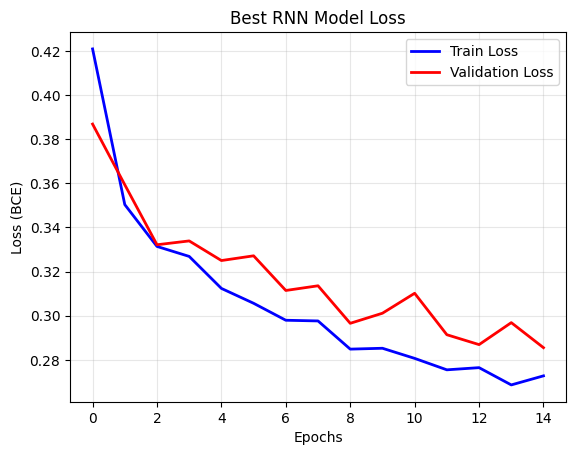

In [52]:
# Plotting Loss
plt.plot(rnn_history['train_loss'], label='Train Loss', color='blue', lw=2)
plt.plot(rnn_history['val_loss'], label='Validation Loss', color='red', lw=2)
plt.title('Best RNN Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (BCE)')
plt.legend()
plt.grid(alpha=0.3)

## Evaluating RNN Model


EVALUATING BEST RNN MODEL ON TEST SET
Test Accuracy:  0.8861
Test Precision: 0.9125
Test Recall:    0.8799
Test F1 Score:  0.8959

Confusion Matrix:
[[657  78]
 [111 813]]

--- Breakdown ---
True Negatives (TN):  657
False Positives (FP): 78
False Negatives (FN): 111
True Positives (TP):  813


<Figure size 600x500 with 0 Axes>

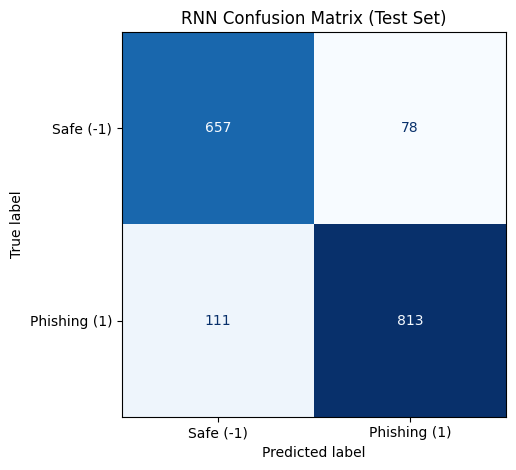

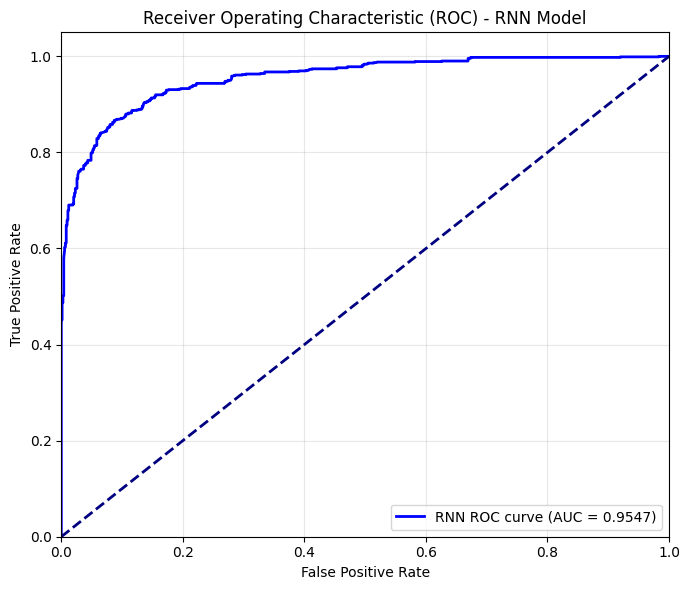

In [53]:
# Evaluating RNN Model
rnn_test_model, rnn_test_preds, rnn_test_probs, rnn_results= evaluate_on_test(rnn_best_params, 'rnn', X_test_t, y_test, device)

cm_rnn = confusion_matrix(y_test, rnn_test_preds)
disp_rnn = ConfusionMatrixDisplay(confusion_matrix=cm_rnn, display_labels=['Safe (-1)', 'Phishing (1)'])

plt.figure(figsize=(6, 5))
cm_rnn = confusion_matrix(y_test, rnn_test_preds)
disp_rnn = ConfusionMatrixDisplay(confusion_matrix=cm_rnn, display_labels=['Safe (-1)', 'Phishing (1)'])
disp_rnn.plot(cmap='Blues', colorbar=False)
plt.title('RNN Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 6))
fpr_rnn, tpr_rnn, _ = roc_curve(y_test, rnn_test_probs)
roc_auc_rnn = auc(fpr_rnn, tpr_rnn)

plt.plot(fpr_rnn, tpr_rnn, color='blue', lw=2, label=f'RNN ROC curve (AUC = {roc_auc_rnn:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - RNN Model')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



### Feature Importance - RNN


Top 15 Feature Importances for RNN:
                 Feature Importance (%)  Raw F1 Drop
             web_traffic         13.25%     0.074102
           prefix_suffix         10.08%     0.056401
       having_sub_domain          9.85%     0.055096
       having_ip_address          6.64%     0.037117
                     sfh          5.61%     0.031359
      shortining_service          4.98%     0.027839
              url_length          4.73%     0.026444
               dnsrecord          4.51%     0.025240
           links_in_tags          4.29%     0.024017
double_slash_redirecting          4.18%     0.023385
           age_of_domain          4.01%     0.022443
               page_rank          3.55%     0.019844
  links_pointing_to_page          2.97%     0.016625
            google_index          2.88%     0.016089
             popupwindow          2.37%     0.013254


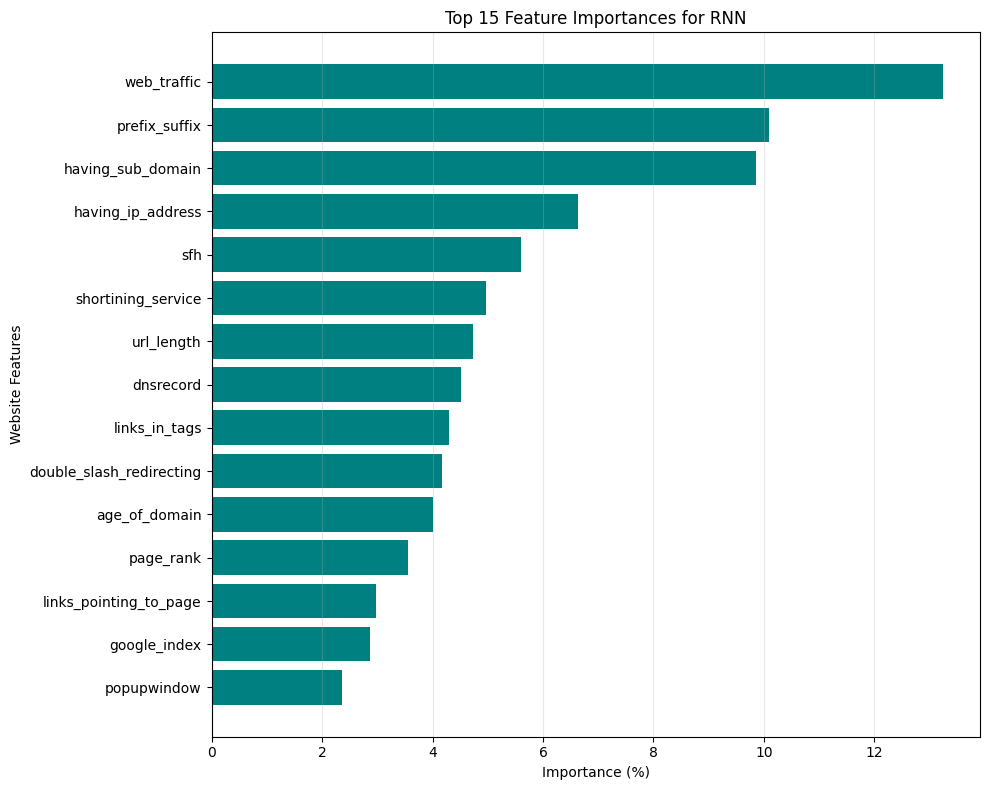

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

In [54]:
# RNN Feature Importance
rnn_feature_names = df.drop(["result", "sslfinal_state", "url_of_anchor"], axis=1).columns.tolist()

if len(rnn_feature_names) != X_test_scaled.shape[1]:
    rnn_feature_names = [f"Feature_{i}" for i in range(X_test_scaled.shape[1])]

rnn_importance_df = permutation_feature_importance(
    model=rnn_test_model,
    X_test_scaled=X_test_scaled,
    y_test=y_test,
    feature_names=rnn_feature_names,
    device=device,
    title="RNN"
)

plt.figure(figsize=(10, 8))


In [55]:
model_results.append({
    'Model': 'RNN (Reduced Features)',
    'Accuracy': rnn_results["accuracy"],
    'Precision': rnn_results["precision"],
    'Recall': rnn_results["recall"],
    'F1 Score': rnn_results["f1"]
})

roc_curves_results.append({
    'Model': 'RNN (Reduced Features)',
    'fpr': fpr_rnn,
    'tpr': tpr_rnn,
    'roc_auc': roc_auc_rnn
})

# GRU

## Training and Validating GRU Model

In [56]:
# Training and Validating GRU Model
gru_results_df, gru_best_params, gru_history, gru_best_score = run_architecture_search('gru')



STARTING TUNING FOR ARCHITECTURE: GRU

--- Testing GRU Combination 1/16 ---
{'activation': 'relu', 'dropout_rate': 0.2, 'hidden_size': 16, 'lr': 0.001}
  Epoch  1/15 - loss: 0.5671 - val_loss: 0.4314
  Epoch  2/15 - loss: 0.3930 - val_loss: 0.3882
  Epoch  3/15 - loss: 0.3685 - val_loss: 0.3760
  Epoch  4/15 - loss: 0.3555 - val_loss: 0.3667
  Epoch  5/15 - loss: 0.3443 - val_loss: 0.3625
  Epoch  6/15 - loss: 0.3339 - val_loss: 0.3543
  Epoch  7/15 - loss: 0.3297 - val_loss: 0.3424
  Epoch  8/15 - loss: 0.3277 - val_loss: 0.3440
  Epoch  9/15 - loss: 0.3212 - val_loss: 0.3365
  Epoch 10/15 - loss: 0.3199 - val_loss: 0.3309
  Epoch 11/15 - loss: 0.3126 - val_loss: 0.3298
  Epoch 12/15 - loss: 0.3080 - val_loss: 0.3268
  Epoch 13/15 - loss: 0.3042 - val_loss: 0.3225
  Epoch 14/15 - loss: 0.3043 - val_loss: 0.3183
  Epoch 15/15 - loss: 0.3006 - val_loss: 0.3192
Validation F1 Score: 0.8662

--- Testing GRU Combination 2/16 ---
{'activation': 'relu', 'dropout_rate': 0.2, 'hidden_size': 16

## Plotting Loss

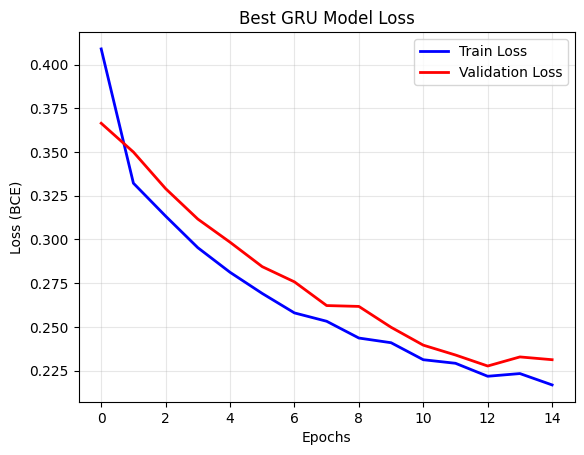

In [57]:
plt.plot(gru_history['train_loss'], label='Train Loss', color='blue', lw=2)
plt.plot(gru_history['val_loss'], label='Validation Loss', color='red', lw=2)
plt.title('Best GRU Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (BCE)')
plt.legend()
plt.grid(alpha=0.3)

## Evaluating GRU Model


EVALUATING BEST GRU MODEL ON TEST SET
Test Accuracy:  0.8987
Test Precision: 0.9266
Test Recall:    0.8885
Test F1 Score:  0.9072

Confusion Matrix:
[[670  65]
 [103 821]]

--- Breakdown ---
True Negatives (TN):  670
False Positives (FP): 65
False Negatives (FN): 103
True Positives (TP):  821


<Figure size 600x500 with 0 Axes>

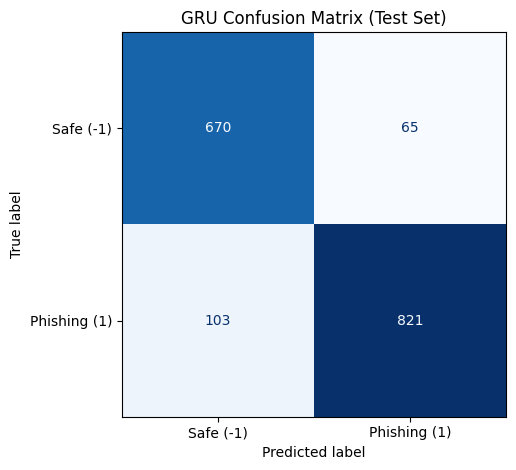

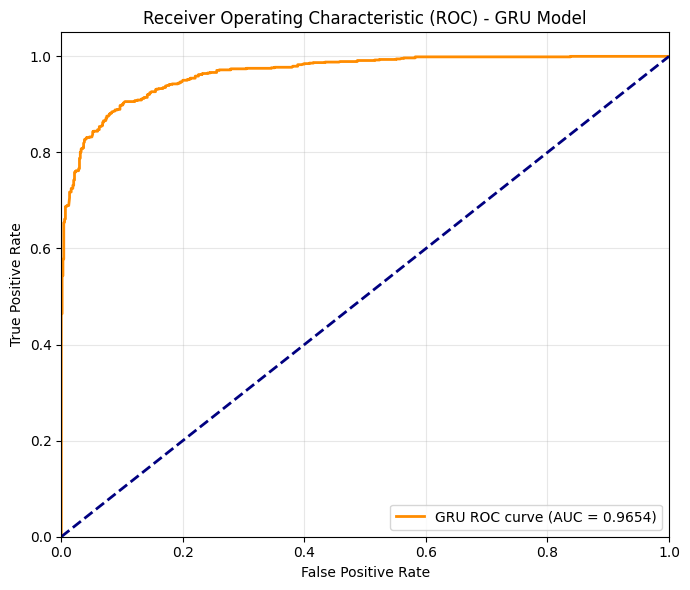

In [58]:
# Evaluating GRU Model
gru_test_model, gru_test_preds, gru_test_probs, gru_results = evaluate_on_test(gru_best_params, 'gru', X_test_t, y_test, device)

cm_gru = confusion_matrix(y_test, gru_test_preds)
disp_gru = ConfusionMatrixDisplay(confusion_matrix=cm_gru, display_labels=['Safe (-1)', 'Phishing (1)'])

fpr_gru, tpr_gru, _ = roc_curve(y_test, gru_test_probs)
roc_auc_gru = auc(fpr_gru, tpr_gru)

plt.figure(figsize=(6, 5))
cm_gru = confusion_matrix(y_test, gru_test_preds)
disp_gru = ConfusionMatrixDisplay(confusion_matrix=cm_gru, display_labels=['Safe (-1)', 'Phishing (1)'])
disp_gru.plot(cmap='Blues', colorbar=False)
plt.title('GRU Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 6))
fpr_gru, tpr_gru, _ = roc_curve(y_test, gru_test_probs)
roc_auc_gru = auc(fpr_gru, tpr_gru)

plt.plot(fpr_gru, tpr_gru, color='darkorange', lw=2, label=f'GRU ROC curve (AUC = {roc_auc_gru:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - GRU Model')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Feature Importance - GRU


Top 15 Feature Importances for GRU:
                   Feature Importance (%)  Raw F1 Drop
               web_traffic         13.43%     0.078285
             prefix_suffix         10.08%     0.058762
         having_sub_domain          9.86%     0.057459
                       sfh          7.06%     0.041169
         having_ip_address          5.79%     0.033772
                 page_rank          5.61%     0.032723
             links_in_tags          5.44%     0.031698
             age_of_domain          5.03%     0.029320
        shortining_service          4.46%     0.026010
  double_slash_redirecting          4.08%     0.023774
                 dnsrecord          4.02%     0.023436
                url_length          3.74%     0.021811
       submitting_to_email          3.05%     0.017799
                      port          2.84%     0.016583
domain_registration_length          2.61%     0.015231


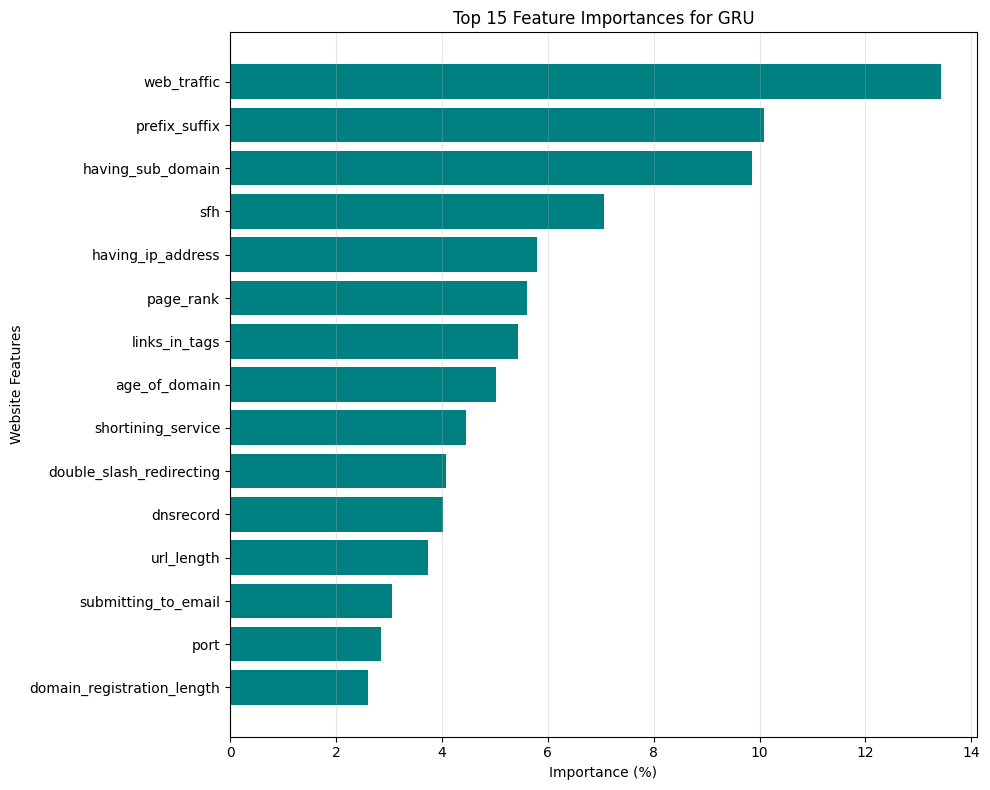

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

In [59]:
# GRU Feature Importance
gru_feature_names = df.drop(["result", "sslfinal_state", "url_of_anchor"], axis=1).columns.tolist()

if len(gru_feature_names) != X_test_scaled.shape[1]:
    gru_feature_names = [f"Feature_{i}" for i in range(X_test_scaled.shape[1])]

gru_importance_df = permutation_feature_importance(
    model=gru_test_model,
    X_test_scaled=X_test_scaled,
    y_test=y_test,
    feature_names=gru_feature_names,
    device=device,
    title="GRU"
)

plt.figure(figsize=(10, 8))


---

In [60]:
model_results.append({
    'Model': 'GRU (Reduced Features)',
    'Accuracy': gru_results["accuracy"],
    'Precision': gru_results["precision"],
    'Recall': gru_results["recall"],
    'F1 Score': gru_results["f1"]
})

roc_curves_results.append({
    'Model': 'gru (Reduced Features)',
    'fpr': fpr_gru,
    'tpr': tpr_gru,
    'roc_auc': roc_auc_gru
})

# Deep Factorization FM

## Initial Setup

In [61]:
# Importing additional library
# import copy

In [62]:
# Remapping to positive values for DeepFM
X_train_cat = X_train + 1
X_val_cat = X_val + 1
X_test_cat = X_test + 1

# Converting features to LongTensors
X_train_t = torch.LongTensor(X_train_cat)
X_val_t = torch.LongTensor(X_val_cat)
X_test_t = torch.LongTensor(X_test_cat)

# Converting targets to FloatTensors
y_train_t = torch.FloatTensor(y_train).unsqueeze(1)
y_val_t = torch.FloatTensor(y_val).unsqueeze(1)
y_test_t = torch.FloatTensor(y_test).unsqueeze(1)

batch_size = 32
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=batch_size, shuffle=False)

## Building model

In [63]:
class DeepFM(nn.Module):
    def __init__(self, num_fields, num_categories=3, embedding_dim=8, hidden_units=[32, 16], dropout_rate=0.2):
        super().__init__()
        self.num_fields = num_fields
        self.embedding_dim = embedding_dim

        # Shared Embedding Layer
        self.embeddings = nn.ModuleList([
            nn.Embedding(num_categories, embedding_dim) for _ in range(num_fields)
        ])

        # First-order linear weights (Wide component)
        self.first_order_embeddings = nn.ModuleList([
            nn.Embedding(num_categories, 1) for _ in range(num_fields)
        ])
        self.bias = nn.Parameter(torch.zeros(1))

        # Deep Component (MLP)
        input_dim = num_fields * embedding_dim
        layers = []
        for hidden_dim in hidden_units:
            layers.append(nn.Linear(input_dim, hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            input_dim = hidden_dim
        layers.append(nn.Linear(input_dim, 1))
        self.dnn = nn.Sequential(*layers)

    def forward(self, x):
        batch_size = x.size(0)

        # First-Order Component
        first_order_terms = [self.first_order_embeddings[i](x[:, i]) for i in range(self.num_fields)]
        first_order_out = torch.sum(torch.cat(first_order_terms, dim=1), dim=1, keepdim=True) + self.bias

        # Second-Order (FM) Component
        embed_list = [self.embeddings[i](x[:, i]) for i in range(self.num_fields)]
        embed_stacked = torch.stack(embed_list, dim=1) # (batch_size, num_fields, embedding_dim)

        sum_embed = torch.sum(embed_stacked, dim=1)
        sum_embed_squared = sum_embed ** 2
        squared_sum_embed = torch.sum(embed_stacked ** 2, dim=1)

        fm_out = 0.5 * torch.sum(sum_embed_squared - squared_sum_embed, dim=1, keepdim=True)

        # Deep Component (MLP)
        dnn_input = embed_stacked.view(batch_size, -1)
        dnn_out = self.dnn(dnn_input)

        # Output
        output = first_order_out + fm_out + dnn_out
        return output

# Evaluating validation data
def evaluate_model(model, X_data, y_true, device):
    """Evaluates the model and returns the F1 score."""
    model.eval()
    with torch.no_grad():
        logits = model(X_data.to(device))
        y_pred_prob = torch.sigmoid(logits).cpu().numpy().ravel()
        y_pred = (y_pred_prob > 0.5).astype(int)
        score = f1_score(y_true, y_pred)
    return score


## Training and Validation

In [64]:
# Defining the grid search
param_grid = {
    'embedding_dim': [4, 8],
    'dropout_rate': [0.2, 0.4],
    'lr': [0.001, 0.005]
}
grid = list(ParameterGrid(param_grid))
epochs = 15
num_features = X_train_t.shape[1]

print(f"\n{'='*50}")
print(f"STARTING GRID SEARCH FOR DEEPFM")
print(f"{'='*50}\n")

best_score = 0
best_params = None
best_history = None
best_model_weights = None
results = []

for i, params in enumerate(grid):
    print(f"--- Testing Combination {i+1}/{len(grid)} ---")
    print(params)

    history = {'train_loss': [], 'val_loss': []}

    model = DeepFM(
        num_fields=num_features,
        embedding_dim=params['embedding_dim'],
        hidden_units=[32, 16],
        dropout_rate=params['dropout_rate']
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=params['lr'])
    criterion = nn.BCEWithLogitsLoss()

    for epoch in range(epochs):
        # Training Phase
        model.train()
        running_train_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            running_train_loss += loss.item()

        # Validation Phase
        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                val_logits = model(xb)
                v_loss = criterion(val_logits, yb)
                running_val_loss += v_loss.item()

        epoch_train_loss = running_train_loss / len(train_loader)
        epoch_val_loss = running_val_loss / len(val_loader)

        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)

        print(f"  Epoch {epoch+1:2d}/{epochs} - loss: {epoch_train_loss:.4f} - val_loss: {epoch_val_loss:.4f}")

    comb_f1 = evaluate_model(model, X_val_t, y_val, device)
    print(f"Validation F1 Score: {comb_f1:.4f}\n")

    results.append({'Params': params, 'F1 Score': comb_f1})

    if comb_f1 > best_score:
        best_score = comb_f1
        best_params = params
        best_history = history
        best_model_weights = copy.deepcopy(model.state_dict())

print(f"\n{'*'*40}")
print("BEST DEEPFM RESULTS")
print(f"{'*'*40}")
print(f"Best Validation F1 Score: {best_score:.4f}")
print("Best Parameters:")
for key, value in best_params.items():
    print(f"  - {key}: {value}")
print(f"{'*'*40}\n")


STARTING GRID SEARCH FOR DEEPFM

--- Testing Combination 1/8 ---
{'dropout_rate': 0.2, 'embedding_dim': 4, 'lr': 0.001}
  Epoch  1/15 - loss: 4.9081 - val_loss: 2.5412
  Epoch  2/15 - loss: 2.1932 - val_loss: 1.8402
  Epoch  3/15 - loss: 1.7740 - val_loss: 1.5683
  Epoch  4/15 - loss: 1.4783 - val_loss: 1.2464
  Epoch  5/15 - loss: 1.2777 - val_loss: 1.1227
  Epoch  6/15 - loss: 1.1167 - val_loss: 0.9899
  Epoch  7/15 - loss: 1.0292 - val_loss: 0.8868
  Epoch  8/15 - loss: 0.9471 - val_loss: 0.8483
  Epoch  9/15 - loss: 0.8110 - val_loss: 0.7326
  Epoch 10/15 - loss: 0.7613 - val_loss: 0.6975
  Epoch 11/15 - loss: 0.7103 - val_loss: 0.6202
  Epoch 12/15 - loss: 0.6572 - val_loss: 0.5858
  Epoch 13/15 - loss: 0.6189 - val_loss: 0.5725
  Epoch 14/15 - loss: 0.5857 - val_loss: 0.6595
  Epoch 15/15 - loss: 0.5452 - val_loss: 0.4921
Validation F1 Score: 0.8430

--- Testing Combination 2/8 ---
{'dropout_rate': 0.2, 'embedding_dim': 4, 'lr': 0.005}
  Epoch  1/15 - loss: 3.7796 - val_loss: 1.

## Evaluating Deep Factorization FM with Test

In [65]:
print(f"\n{'='*50}")
print("EVALUATING BEST DEEPFM MODEL ON TEST SET")
print(f"{'='*50}")

# Load the best model weights
final_model = DeepFM(
    num_fields=num_features,
    embedding_dim=best_params['embedding_dim'],
    hidden_units=[32, 16],
    dropout_rate=best_params['dropout_rate']
).to(device)
final_model.load_state_dict(best_model_weights)

# Evaluate on Test Set
final_model.eval()
with torch.no_grad():
    test_logits = final_model(X_test_t.to(device))
    y_pred_prob = torch.sigmoid(test_logits).cpu().numpy().ravel()
    y_pred = (y_pred_prob > 0.5).astype(int)

# Calculate Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
cm = confusion_matrix(y_test, y_pred)

print(f"Test Accuracy:  {acc:.4f}")
print(f"Test Precision: {prec:.4f}")
print(f"Test Recall:    {rec:.4f}")
print(f"Test F1 Score:  {f1:.4f}")

tn, fp, fn, tp = cm.ravel()
print("\n--- Confusion Matrix Breakdown ---")
print(f"True Negatives (TN):  {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP):  {tp}")


EVALUATING BEST DEEPFM MODEL ON TEST SET
Test Accuracy:  0.8499
Test Precision: 0.8610
Test Recall:    0.8712
Test F1 Score:  0.8661

--- Confusion Matrix Breakdown ---
True Negatives (TN):  605
False Positives (FP): 130
False Negatives (FN): 119
True Positives (TP):  805


## Plot (Loss, Confusion Matric, ROC Curve)

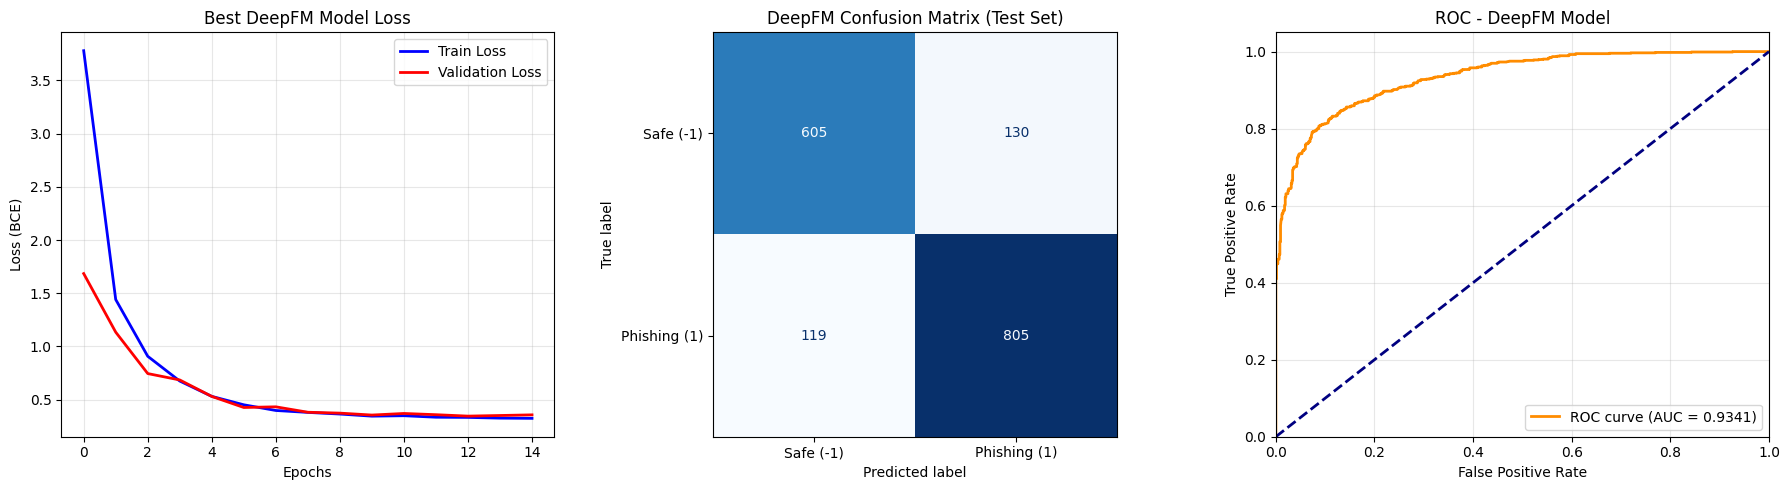

In [66]:
# Plot 1: Train vs Validation Loss
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(best_history['train_loss'], label='Train Loss', color='blue', lw=2)
plt.plot(best_history['val_loss'], label='Validation Loss', color='red', lw=2)
plt.title('Best DeepFM Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (BCE)')
plt.legend()
plt.grid(alpha=0.3)

# Plot 2: Confusion Matrix
plt.subplot(1, 3, 2)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Safe (-1)', 'Phishing (1)'])
disp.plot(ax=plt.gca(), cmap='Blues', colorbar=False)
plt.title('DeepFM Confusion Matrix (Test Set)')

# Plot 3: ROC Curve
plt.subplot(1, 3, 3)
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC - DeepFM Model')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Feature Importance - Deep Factorization FM


CALCULATING FEATURE IMPORTANCE

Top 15 Feature Importances:
           Feature Importance (%)  Raw F1 Drop
       web_traffic         13.70%     0.054846
 having_sub_domain         11.52%     0.046142
     prefix_suffix         11.39%     0.045598
 having_ip_address          6.92%     0.027695
               sfh          5.77%     0.023108
       https_token          4.64%     0.018599
shortining_service          4.62%     0.018489
         page_rank          3.81%     0.015263
       popupwindow          3.66%     0.014656
              port          3.62%     0.014499
           favicon          3.39%     0.013581
     age_of_domain          2.99%     0.011957
            iframe          2.65%     0.010597
        url_length          2.42%     0.009680
         dnsrecord          2.38%     0.009519


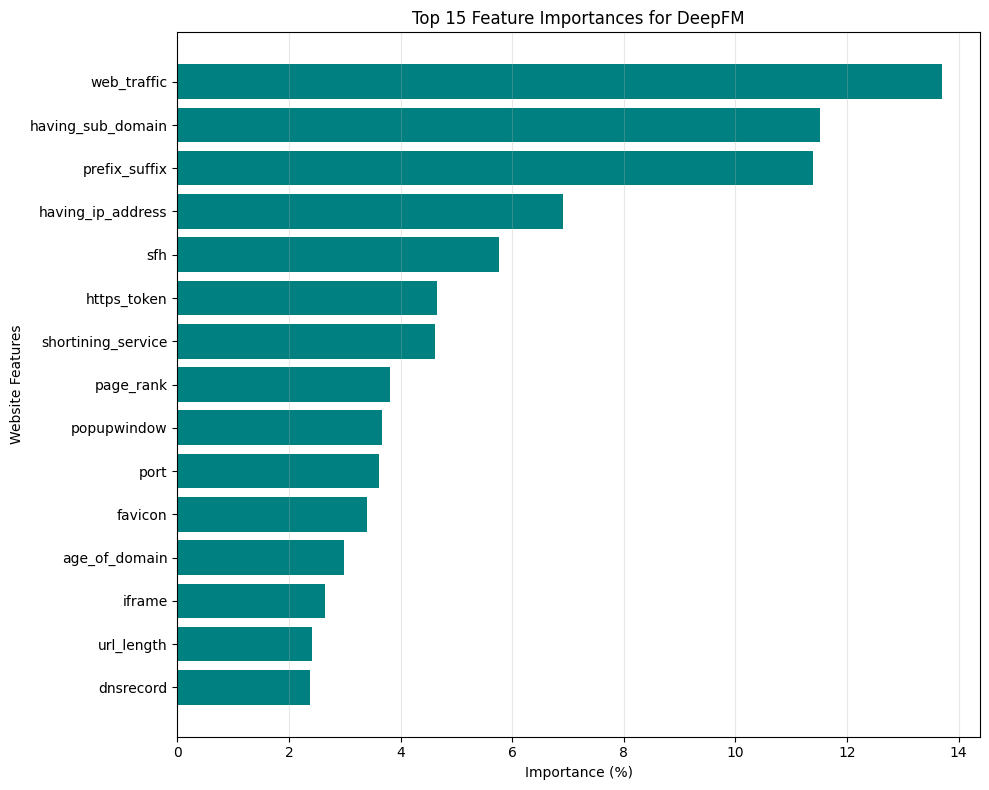

In [67]:
# Feature Importance
print(f"\n{'='*50}")
print("CALCULATING FEATURE IMPORTANCE")
print(f"{'='*50}")

feature_names = df.drop(['result', 'sslfinal_state', 'url_of_anchor'], axis=1).columns.tolist()

if len(feature_names) != X_test_cat.shape[1]:
    print("Warning: Lengths still do not match. Falling back to generic names.")
    feature_names = [f"Feature_{i}" for i in range(X_test_cat.shape[1])]

baseline_f1 = f1
importances = []

for i in range(X_test_cat.shape[1]):
    X_test_shuffled = X_test_cat.copy()
    np.random.shuffle(X_test_shuffled[:, i])

    X_shuffled_t = torch.LongTensor(X_test_shuffled).to(device)

    final_model.eval()
    with torch.no_grad():
        shuffled_logits = final_model(X_shuffled_t)
        y_pred_shuffled_prob = torch.sigmoid(shuffled_logits).cpu().numpy().ravel()

    y_pred_shuffled = (y_pred_shuffled_prob > 0.5).astype(int)

    shuffled_f1 = f1_score(y_test, y_pred_shuffled, zero_division=0)
    drop_in_score = baseline_f1 - shuffled_f1
    importances.append(drop_in_score)

importances_array = np.array(importances)
importances_clipped = np.maximum(importances_array, 0)

total_importance = importances_clipped.sum()
if total_importance == 0:
    importance_percentages = importances_clipped * 0
else:
    importance_percentages = (importances_clipped / total_importance) * 100

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Raw F1 Drop': importances_array,
    'Importance (%)': importance_percentages
}).sort_values(by='Importance (%)', ascending=True)

print("\nTop 15 Feature Importances:")
display_df = importance_df.tail(15).copy()
display_df['Importance (%)'] = display_df['Importance (%)'].apply(lambda x: f"{x:.2f}%")
print(display_df[::-1][['Feature', 'Importance (%)', 'Raw F1 Drop']].to_string(index=False))

plt.figure(figsize=(10, 8))
top_15 = importance_df.tail(15)

plt.barh(top_15['Feature'], top_15['Importance (%)'], color='teal')
plt.xlabel('Importance (%)')
plt.ylabel('Website Features')
plt.title('Top 15 Feature Importances for DeepFM')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [68]:
model_results.append({
    'Model': 'DeepFM (Reduced Features)',
    'Accuracy': acc,
    'Precision': prec,
    'Recall': rec,
    'F1 Score': f1
})

roc_curves_results.append({
    'Model': 'DeepFM (Reduced Features)',
    'fpr': fpr,
    'tpr': tpr,
    'roc_auc': roc_auc
})

                           Model  Accuracy  Precision   Recall  F1 Score
                   Random Forest  0.962025   0.962265 0.962025  0.961957
                         XGBoost  0.963231   0.961497 0.972944  0.967187
                             RNN  0.951153   0.945282 0.968318  0.956661
                             GNN  0.960199   0.960190 0.960199  0.960182
Random Forest (Reduced Features)  0.918626   0.918576 0.918626  0.918560
      XGBoost (Reduced Features)  0.921037   0.928649 0.929654  0.929151
          GNN (Reduced Features)  0.883665   0.884418 0.883665  0.883840
          RNN (Reduced Features)  0.886076   0.912458 0.879870  0.895868
          GRU (Reduced Features)  0.898734   0.926637 0.888528  0.907182
       DeepFM (Reduced Features)  0.849910   0.860963 0.871212  0.866057


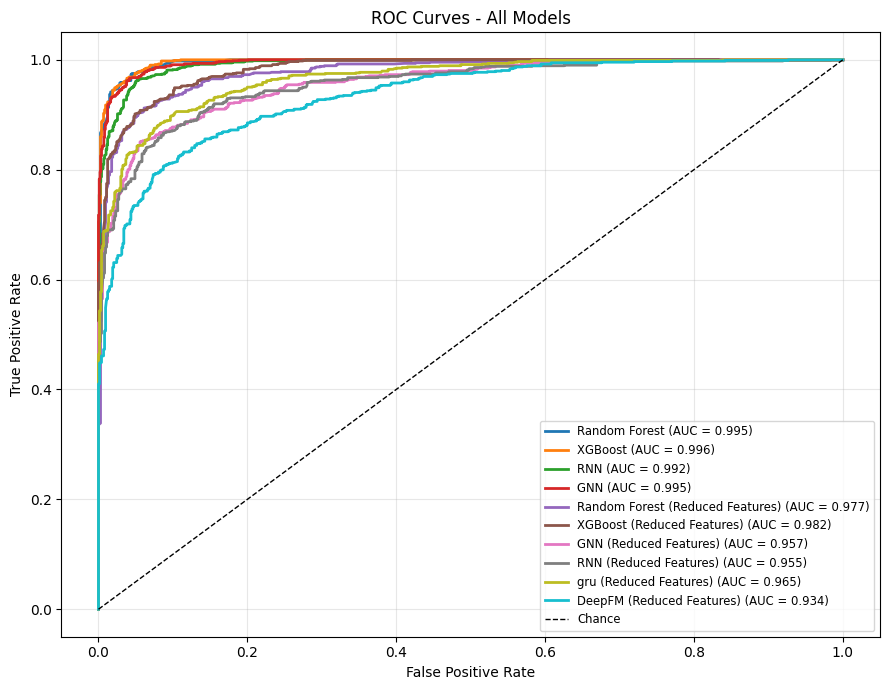

In [69]:
# Displaying results with full dataset
comparison_df = pd.DataFrame(model_results)
comparison_df = comparison_df[[
    "Model", "Accuracy", "Precision", "Recall", "F1 Score"
]]
comparison_df.index = np.arange(1, len(comparison_df) + 1)
print(comparison_df.to_string(index=False))

# Plotting ROC Curve
plt.figure(figsize=(9, 7))
for item in roc_curves_results:
    plt.plot(item["fpr"], item["tpr"], lw=2, label=f'{item["Model"]} (AUC = {item["roc_auc"]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Models')
plt.legend(loc='lower right', fontsize='small')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
